# **🗃️ Import Libraries**

In [1]:
# Import essential libraries
import pandas as pd
import numpy as np
import os
import logging
import time
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            confusion_matrix, classification_report, roc_curve, auc,
                            roc_auc_score, precision_recall_curve, average_precision_score)
from sklearn.utils import class_weight
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# **📊 Understanding the Dataset and Dataset Loading**

## **🔍 Introduction**

The "Student's Performance Dataset" presents a comprehensive panorama of factors influencing high school students' academic achievement. With data from 2,392 students covering various aspects of their lives, this dataset opens a window of opportunity to uncover hidden patterns and relationships that determine academic success. Through exploration of this dataset, we can build predictive models that have the potential to revolutionize educational strategies and learning interventions.

## **🌐 Data Source**

This dataset is sourced from Kaggle, titled "Student's Performance Dataset" developed by Rabie El Kharoua ([Kaggle link](https://www.kaggle.com/datasets/rabieelkharoua/students-performance-dataset)). Released in 2024 under the CC BY 4.0 license, this dataset is synthetic data designed specifically for educational research purposes. Although synthetic, the dataset is modeled based on patterns and correlations found in real-world contexts, providing a strong foundation for predictive analysis in the field of education.

## **📋 Variables Used**

The dataset contains 15 variables that can be grouped into several main categories:

### **👤 Demographic Information**
- **StudentID**: Unique identifier for each student (range 1001-3392)
- **Age**: Student age (15-18 years)
- **Gender**: Student gender (0: Male, 1: Female)
- **Ethnicity**: Student ethnic background
  - 0: Caucasian
  - 1: African American
  - 2: Asian
  - 3: Other

### **👪 Family Background**
- **ParentalEducation**: Highest level of parental education
  - 0: None
  - 1: High School
  - 2: Some College
  - 3: Bachelor's
  - 4: Higher
- **ParentalSupport**: Level of support provided by parents
  - 0: None
  - 1: Low
  - 2: Moderate
  - 3: High
  - 4: Very High

### **📚 Study Habits**
- **StudyTimeWeekly**: Number of study hours per week (0-20 hours)
- **Absences**: Number of absences during the school year (0-30)
- **Tutoring**: Participation in tutoring programs (0: No, 1: Yes)

### **🏆 Extracurricular Activities**
- **Extracurricular**: Participation in extracurricular activities (0: No, 1: Yes)
- **Sports**: Participation in sports activities (0: No, 1: Yes)
- **Music**: Participation in music activities (0: No, 1: Yes)
- **Volunteering**: Participation in volunteer activities (0: No, 1: Yes)

### **📝 Academic Performance**
- **GPA**: Grade Point Average with a range of 2.0-4.0
- **GradeClass**: Grade category (target variable)
  - 0: A (GPA ≥ 3.5)
  - 1: B (3.0 ≤ GPA < 3.5)
  - 2: C (2.5 ≤ GPA < 3.0)
  - 3: D (2.0 ≤ GPA < 2.5)
  - 4: F (GPA < 2.0)

The **GradeClass** variable will be the prediction target in our classification models that we'll develop using Logistic Regression, K-Nearest Neighbor, Naïve Bayes, and Decision Tree algorithms. By utilizing the other variables as predictor features, we can identify key factors that influence students' academic performance. ✨

In [2]:
# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler(),    
    ]
)

# Function to load and validate the dataset
def load_student_performance_data(file_path):
    """
    Loads and validates the Student Performance dataset.
    
    Parameters:
    -----------
    file_path : str
        Path to the CSV file containing the dataset
    
    Returns:
    --------
    pandas.DataFrame or None
        The loaded dataset if successful, None otherwise
    """
    # Start a timer to measure loading time
    start_time = time.time()
    
    # Check if the file exists
    if not os.path.exists(file_path):
        logging.error(f"❌ ERROR: File not found at path: {file_path}")
        logging.info(f"💡 TIP: Double-check the file path and make sure the file exists.")
        return None
    
    logging.info(f"🔍 Attempting to load dataset from: {file_path}")
    
    try:
        # Attempt to load the dataset
        df = pd.read_csv(file_path)
        
        # Calculate loading time
        load_time = time.time() - start_time
        
        # Basic validation
        if df.empty:
            logging.error("❌ ERROR: The loaded dataset is empty.")
            return None
        
        # Log success message with fancy formatting
        logging.info(f"✅ SUCCESS: Dataset loaded successfully in {load_time:.2f} seconds!")
        logging.info(f"📊 Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
        
        # Log memory usage
        memory_usage = df.memory_usage(deep=True).sum() / (1024 * 1024)  # Convert to MB
        logging.info(f"💾 Memory usage: {memory_usage:.2f} MB")
        
        # Log column information
        logging.info(f"📋 Columns: {', '.join(df.columns.tolist())}")
        
        # Check for missing values
        missing_values = df.isnull().sum().sum()
        if missing_values > 0:
            logging.warning(f"⚠️ WARNING: Dataset contains {missing_values} missing values.")
        else:
            logging.info("✓ No missing values detected.")
            
        # Check for duplicate rows
        duplicates = df.duplicated().sum()
        if duplicates > 0:
            logging.warning(f"⚠️ WARNING: Dataset contains {duplicates} duplicate rows.")
        else:
            logging.info("✓ No duplicate rows detected.")
             
        return df
    
    except Exception as e:
        logging.error(f"❌ ERROR: Failed to load dataset: {str(e)}")
        logging.info(f"💡 TIP: Check the file format and encoding.")
        return None

# File path
file_path = 'dataset/Student_performance_data _.csv'

# Load the dataset
logging.info("🚀 STARTING DATA LOADING PROCESS...")
logging.info(f"📅 Current time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Load data
df = load_student_performance_data(file_path)

if df is not None:
    logging.info("🎉 DATA LOADING COMPLETED SUCCESSFULLY!")
else:
    logging.error("❌ DATA LOADING FAILED. Please check the errors above.")

2025-05-01 20:01:41,417 - INFO - 🚀 STARTING DATA LOADING PROCESS...
2025-05-01 20:01:41,418 - INFO - 📅 Current time: 2025-05-01 20:01:41
2025-05-01 20:01:41,419 - INFO - 🔍 Attempting to load dataset from: dataset/Student_performance_data _.csv
2025-05-01 20:01:41,425 - INFO - ✅ SUCCESS: Dataset loaded successfully in 0.01 seconds!
2025-05-01 20:01:41,425 - INFO - 📊 Dataset shape: 2392 rows × 15 columns
2025-05-01 20:01:41,428 - INFO - 💾 Memory usage: 0.27 MB
2025-05-01 20:01:41,428 - INFO - 📋 Columns: StudentID, Age, Gender, Ethnicity, ParentalEducation, StudyTimeWeekly, Absences, Tutoring, ParentalSupport, Extracurricular, Sports, Music, Volunteering, GPA, GradeClass
2025-05-01 20:01:41,429 - INFO - ✓ No missing values detected.
2025-05-01 20:01:41,432 - INFO - ✓ No duplicate rows detected.
2025-05-01 20:01:41,433 - INFO - 🎉 DATA LOADING COMPLETED SUCCESSFULLY!


## 📊 **Descriptive Statistics & Initial Data Visualization**

In this section, we dive into an exploratory overview of the dataset through **descriptive statistics** and **preliminary visualizations**. This initial analysis helps us understand the overall structure, distribution, and potential patterns within the data before diving into more complex modeling tasks.

We'll explore:
- Summary statistics for numerical features (e.g., age, GPA, study time, absences)
- Frequency distributions for categorical variables (e.g., gender, ethnicity, parental support)
- Initial visual insights into student performance, study habits, and parental involvement

> 🧭 The goal here is to uncover early insights, detect any anomalies or imbalances, and get a general feel for the data's behavior and characteristics.

### **📐 Numerical Features Overview**

Let's begin by exploring the **numerical columns** in the dataset to understand their central tendencies, spread, and potential outliers. This includes variables such as age, GPA, weekly study time, and absences — key indicators that may influence academic performance.

🔢 DESCRIPTIVE STATISTICS FOR NUMERICAL VARIABLES


,count,mean,std,min,25%,50%,75%,max,range,variance,skewness,kurtosis
Age,2392.000,16.469,1.124,15.000,15.000,16.000,17.000,18.000,3.000,1.263,0.036,-1.372
StudyTimeWeekly,2392.000,9.772,5.653,0.001,5.043,9.705,14.408,19.978,19.977,31.954,0.050,-1.136
Absences,2392.000,14.541,8.467,0.000,7.000,15.000,22.000,29.000,29.000,71.697,-0.026,-1.176
GPA,2392.000,1.906,0.915,0.000,1.175,1.893,2.622,4.000,4.000,0.838,0.015,-0.863
GradeClass,2392.000,2.984,1.234,0.000,2.000,4.000,4.000,4.000,4.000,1.523,-0.901,-0.417



📊 OUTLIER DETECTION USING IQR METHOD
Age: 0 outliers detected (0.00% of data)
StudyTimeWeekly: 0 outliers detected (0.00% of data)
Absences: 0 outliers detected (0.00% of data)
GPA: 0 outliers detected (0.00% of data)
GradeClass: 0 outliers detected (0.00% of data)

📈 DISTRIBUTION OF NUMERICAL VARIABLES


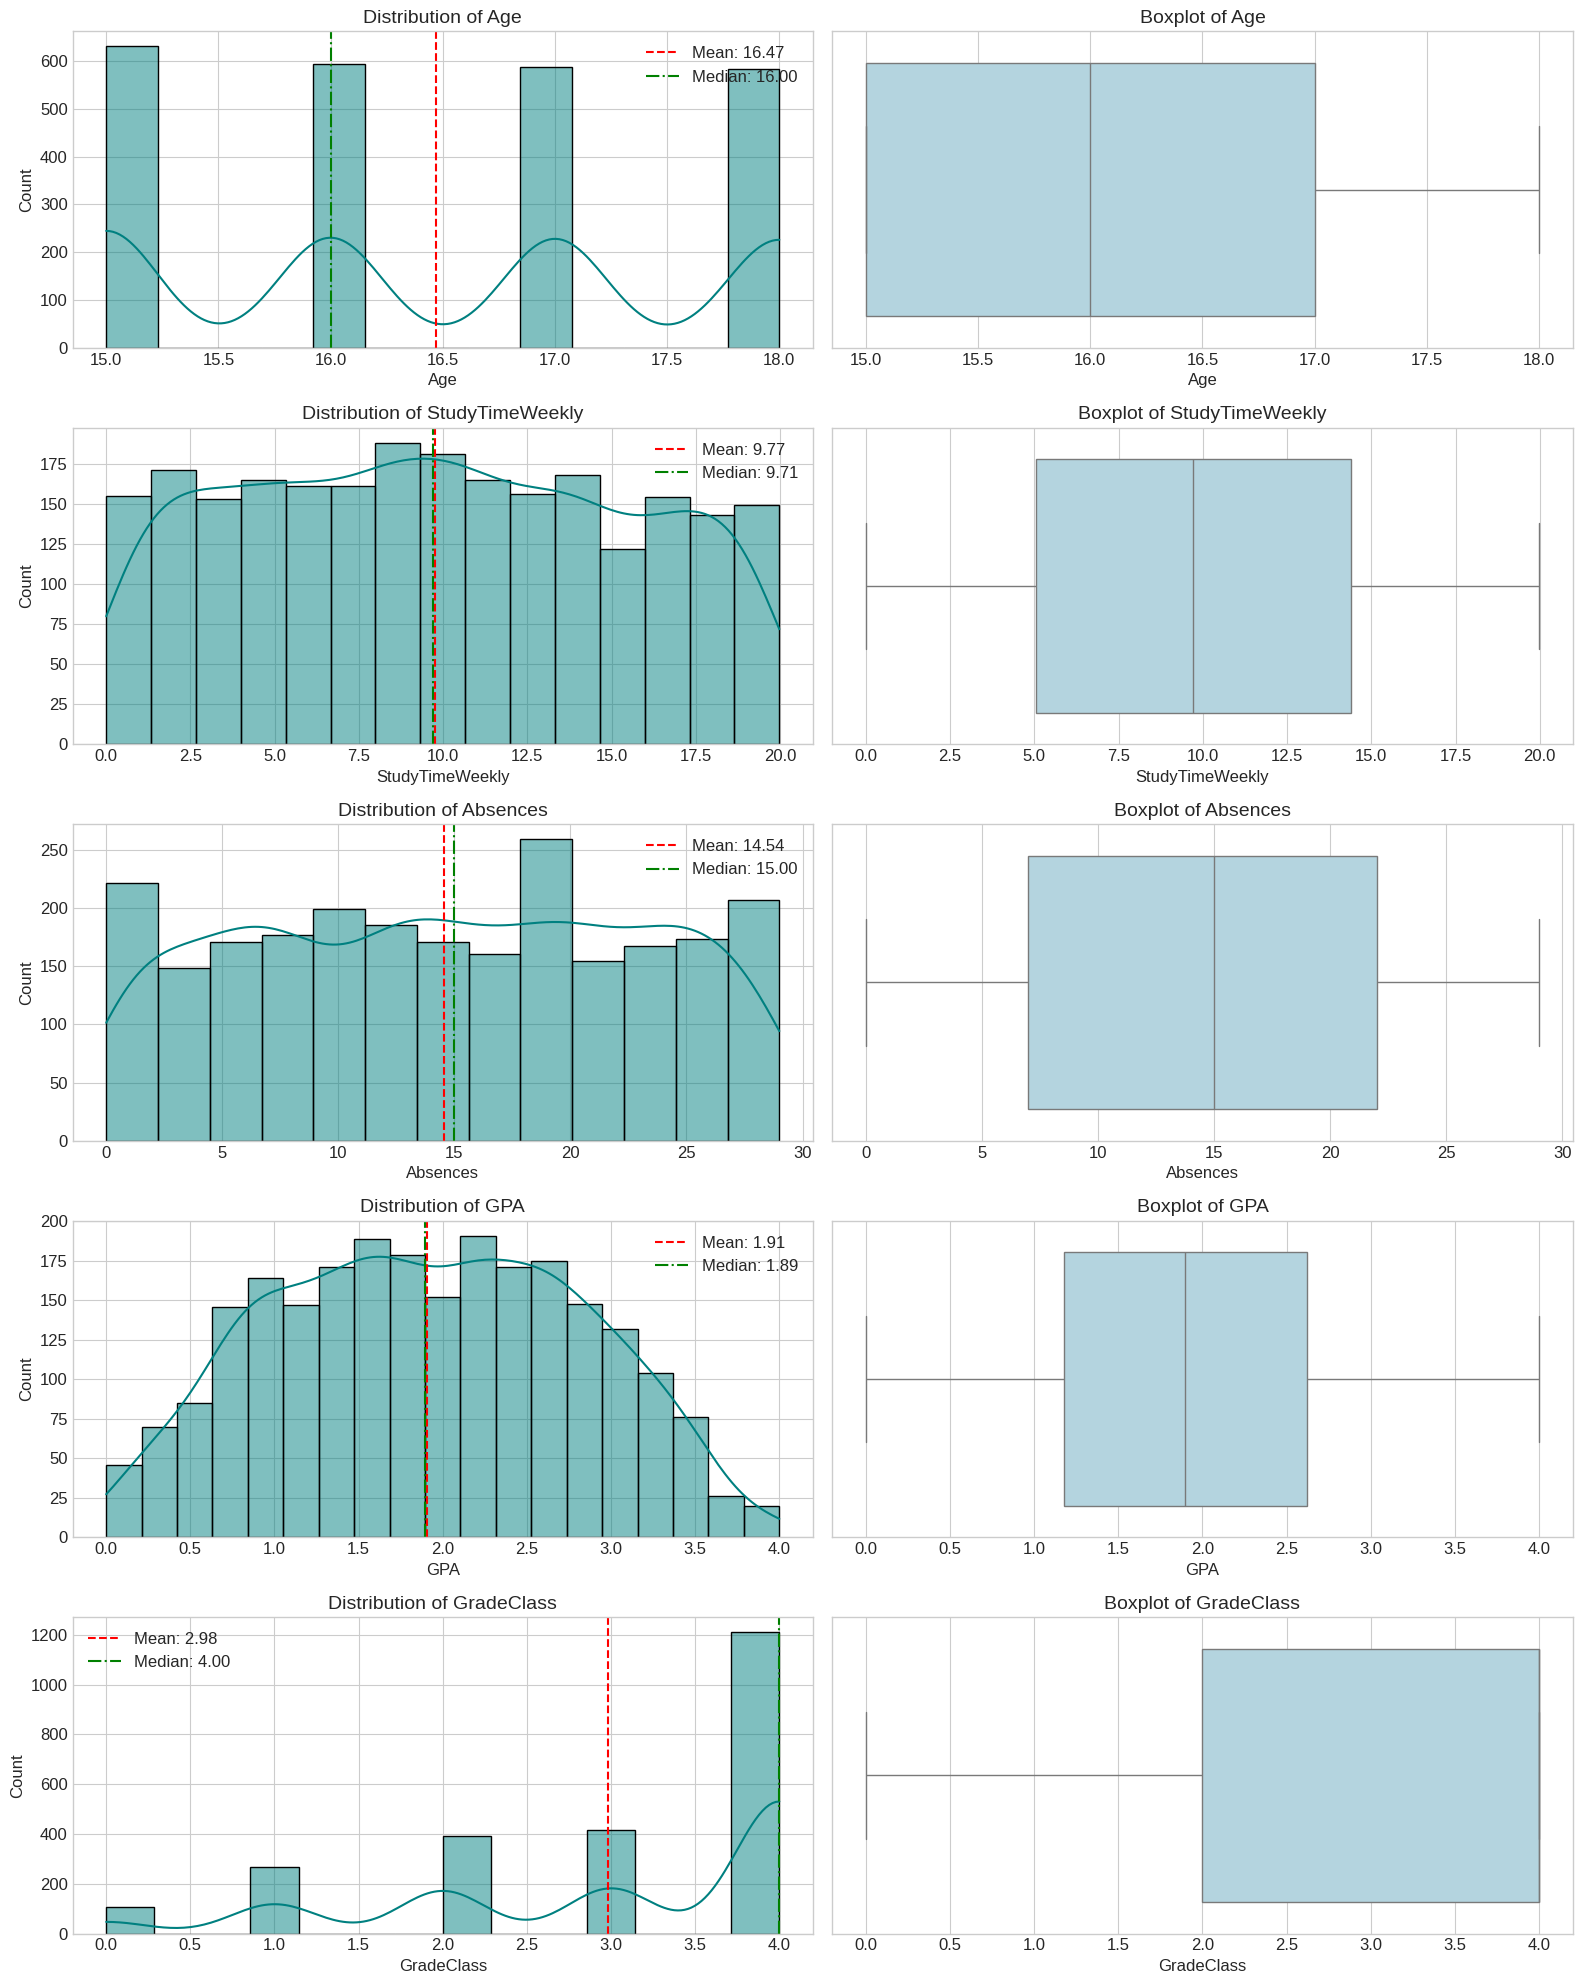


🔗 CORRELATION BETWEEN NUMERICAL VARIABLES


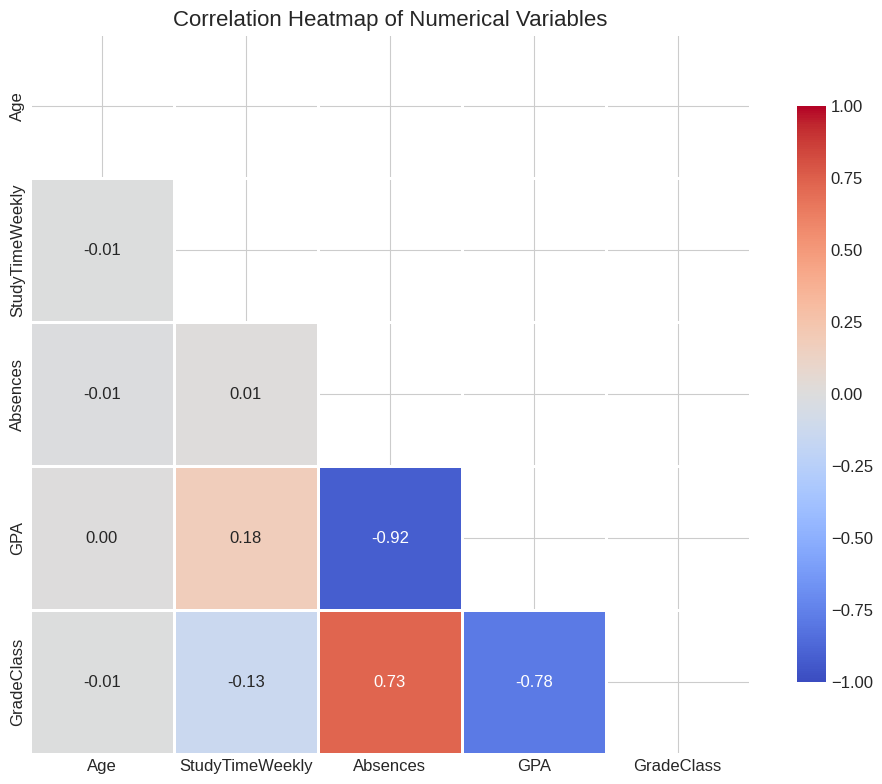

2025-05-01 20:01:43,747 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-01 20:01:43,753 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-01 20:01:43,815 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-01 20:01:43,821 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-01 20:01:43,889 - INFO - Using categorical units to plot a list of strings that are all parsable as 

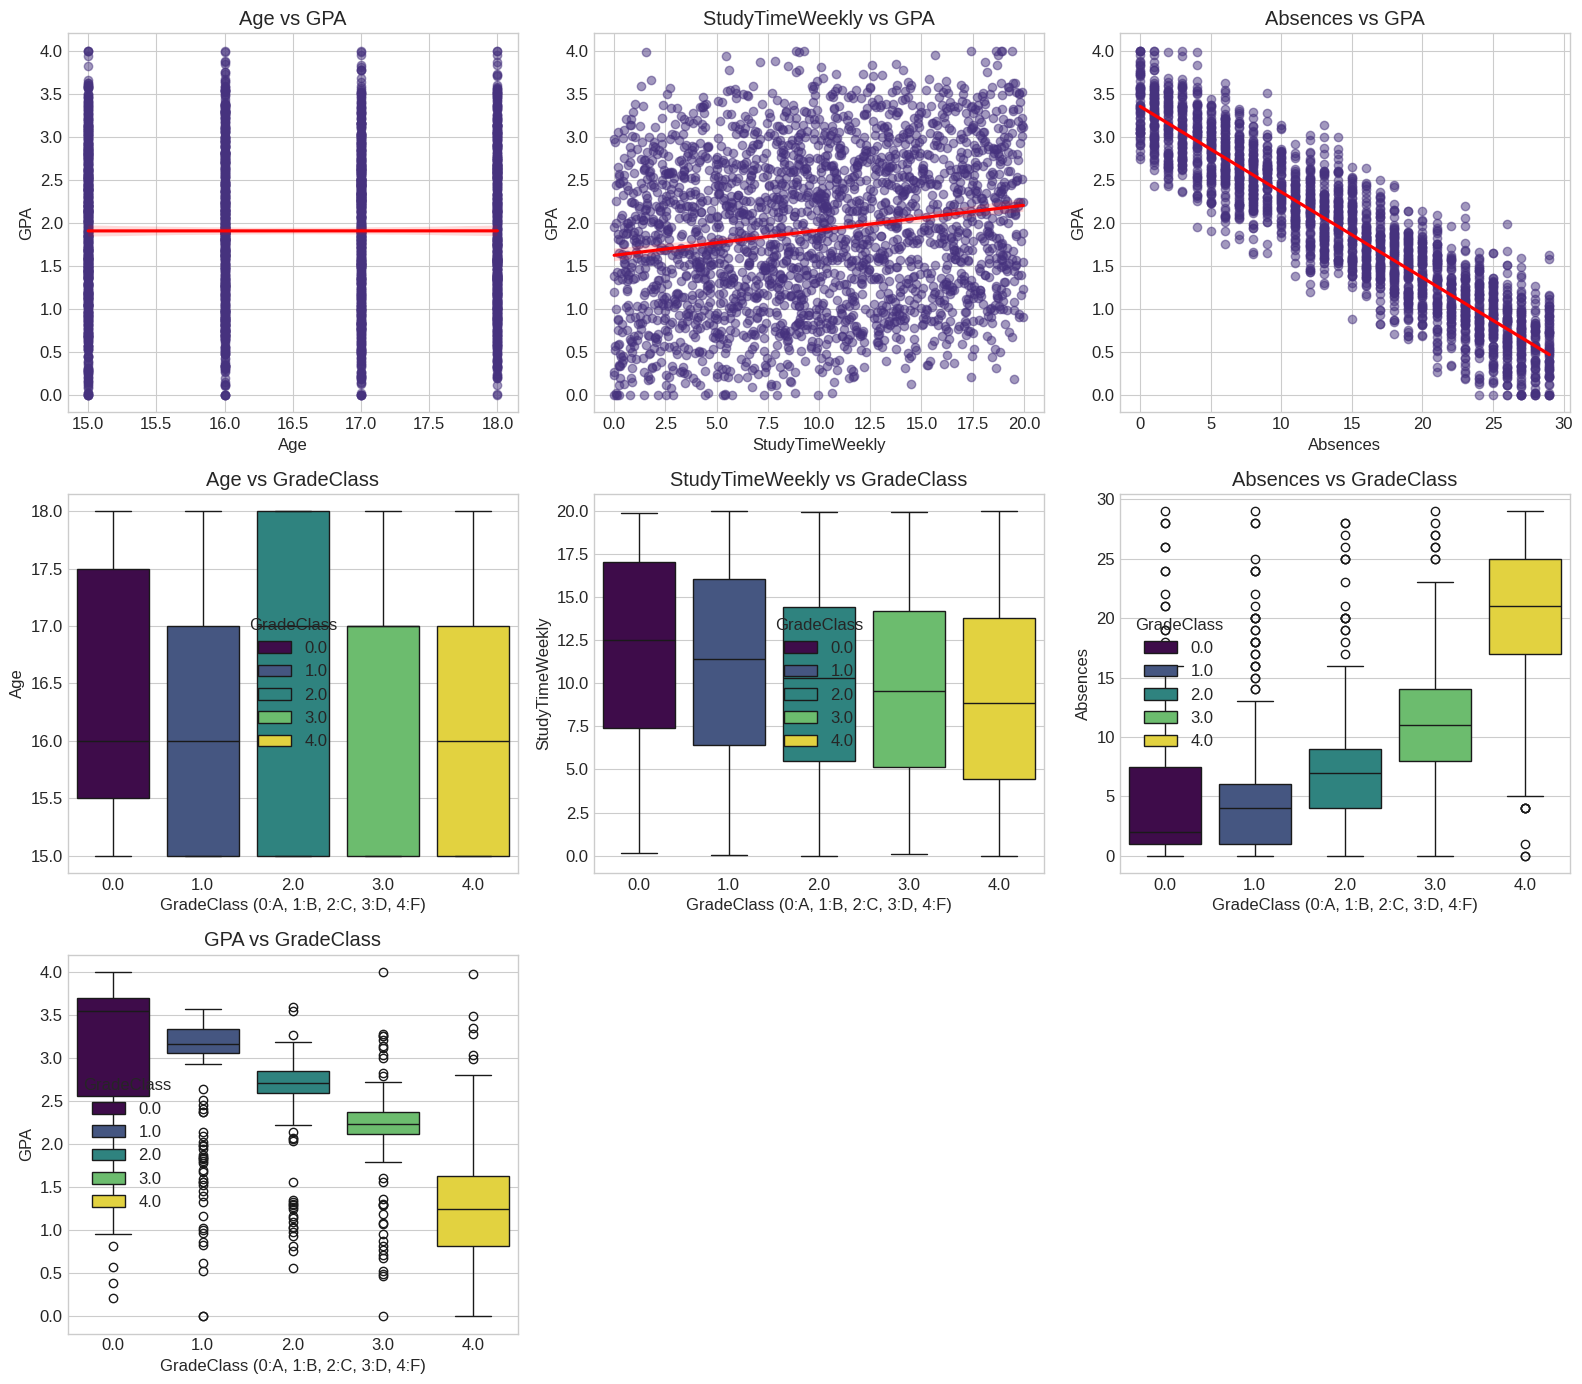

In [3]:
# Identify numerical columns
numerical_cols = ['Age', 'StudyTimeWeekly', 'Absences', 'GPA', 'GradeClass']

# Display descriptive statistics for numerical columns
print("🔢 DESCRIPTIVE STATISTICS FOR NUMERICAL VARIABLES")
print("="*80)
desc_stats = df[numerical_cols].describe().T

# Add additional statistical measures
desc_stats['range'] = desc_stats['max'] - desc_stats['min']
desc_stats['variance'] = df[numerical_cols].var()
desc_stats['skewness'] = df[numerical_cols].skew()
desc_stats['kurtosis'] = df[numerical_cols].kurtosis()

# Format the display
pd.set_option('display.float_format', '{:.3f}'.format)
display(desc_stats)

# Check for outliers using IQR method
print("\n📊 OUTLIER DETECTION USING IQR METHOD")
print("="*80)
for col in numerical_cols:
    Q1 = np.percentile(df[col], 25)
    Q3 = np.percentile(df[col], 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f"{col}: {outliers} outliers detected ({outliers/len(df)*100:.2f}% of data)")

# Plot histograms and boxplots for numerical variables
print("\n📈 DISTRIBUTION OF NUMERICAL VARIABLES")
print("="*80)

fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(16, 4*len(numerical_cols)))
plt.subplots_adjust(hspace=0.5)

for i, col in enumerate(numerical_cols):
    # Histogram with KDE
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='teal')
    axes[i, 0].set_title(f'Distribution of {col}', fontsize=14)
    axes[i, 0].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[i, 0].axvline(df[col].median(), color='green', linestyle='-.', label=f'Median: {df[col].median():.2f}')
    axes[i, 0].legend()
    
    # Box plot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightblue')
    axes[i, 1].set_title(f'Boxplot of {col}', fontsize=14)

plt.tight_layout()
plt.show()

# Correlation analysis for numerical variables
print("\n🔗 CORRELATION BETWEEN NUMERICAL VARIABLES")
print("="*80)

# Calculate correlation matrix
corr_matrix = df[numerical_cols].corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Generate a heatmap with the mask
sns.heatmap(corr_matrix, 
            mask=mask, 
            cmap='coolwarm', 
            vmax=1, 
            vmin=-1, 
            center=0,
            annot=True, 
            fmt='.2f', 
            square=True, 
            linewidths=1, 
            cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap of Numerical Variables', fontsize=16)
plt.tight_layout()
plt.show()

# Scatter plots for relationships with GPA and GradeClass
plt.figure(figsize=(16, 14))

# First row: Relationship with GPA
for i, col in enumerate(['Age', 'StudyTimeWeekly', 'Absences']):
    plt.subplot(3, 3, i+1)
    sns.regplot(x=col, y='GPA', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.title(f'{col} vs GPA')
    
# Second row: Relationship with GradeClass
for i, col in enumerate(['Age', 'StudyTimeWeekly', 'Absences']):
    plt.subplot(3, 3, i+4)
    sns.boxplot(x='GradeClass', y=col, data=df, palette='viridis',  hue='GradeClass')
    plt.title(f'{col} vs GradeClass')
    plt.xlabel('GradeClass (0:A, 1:B, 2:C, 3:D, 4:F)')

# Relationship between GPA and GradeClass
plt.subplot(3, 3, 7)
sns.boxplot(x='GradeClass', y='GPA', data=df, palette='viridis', hue='GradeClass')
plt.title('GPA vs GradeClass')
plt.xlabel('GradeClass (0:A, 1:B, 2:C, 3:D, 4:F)')

plt.tight_layout()
plt.show()

#### 🔍 Key Insights from Numerical Feature Analysis

From our exploration of the numerical features, several important patterns and trends emerge that can inform both our understanding of student behavior and the development of predictive models:

- **🎓 Age Consistency Across the Board**  
  The age distribution (`Age`) is evenly spread between **15 to 18 years**, with an average of **16.47 years**. This confirms the dataset's focus on typical high school students and shows no outliers — a good sign of clean, reliable demographic data.

- **📚 Diverse Study Habits**  
  Weekly study time (`StudyTimeWeekly`) varies considerably, ranging from **0 to 20 hours**, with an average of **9.77 hours/week**. This wide spread — without extreme outliers — reveals significant variation in how students allocate their time for studying, potentially a key driver of performance.

- **🚨 Absenteeism: A Major Concern**  
  The average number of school absences (`Absences`) stands at **14.54 days/year**, with some students missing nearly an entire month (up to 29 days). This high rate of absenteeism raises red flags, especially given its proven link to poor academic performance.

- **📉 Absences Strongly Impact GPA**  
  There's a **very strong negative correlation** between `Absences` and `GPA` (-0.92), and a **positive correlation** with `GradeClass` (0.73). In other words, **more absences almost certainly lead to lower grades** — a trend clearly visible in both correlation maps and grade distribution plots.

- **🧪 Study Time Isn't Everything**  
  While `StudyTimeWeekly` does show a slight positive relationship with `GPA` (0.18), the impact appears to be modest. Even top-performing students (GradeClass 0: A) don’t study drastically more than those in the lowest tier (GradeClass 4: F), suggesting that **other factors (like attendance and support) play a more dominant role**.

- **⚖️ Class Imbalance Alert**  
  A striking insight is the **heavy skew in grade distribution**: over **1,200 students** fall into GradeClass 4 (F), meaning **more than half the students are failing**. This class imbalance must be carefully addressed in any predictive model to prevent bias toward the dominant class.

- **🧼 Clean Data, No Outliers**  
  Using the **IQR method**, no outliers were detected in any numerical column. This adds confidence to the dataset's integrity, allowing us to proceed with modeling without requiring additional cleaning.

> 🧠 These insights paint a vivid picture of student performance and its influencing factors — helping us lay a strong foundation for the next phases of feature engineering and model development.

### **🧩 Categorical Features Overview**

Next, let's explore the **categorical columns** in the dataset to uncover patterns in demographics, parental involvement, and student participation in extracurricular activities. These qualitative variables often hold valuable insights into behavioral and social factors that may influence academic outcomes.

📊 FREQUENCY DISTRIBUTION FOR CATEGORICAL VARIABLES

Gender Distribution:


,Count,Percentage (%)
0 (Male),1170,48.910
1 (Female),1222,51.090



Ethnicity Distribution:


,Count,Percentage (%)
0 (Caucasian),1207,50.460
1 (African American),493,20.610
2 (Asian),470,19.650
3 (Other),222,9.280



ParentalEducation Distribution:


...


GradeClass Distribution:


,Count,Percentage (%)
0.0 (A),107,4.470
1.0 (B),269,11.250
2.0 (C),391,16.350
3.0 (D),414,17.310
4.0 (F),1211,50.630


2025-05-01 20:01:45,302 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-01 20:01:45,307 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-01 20:01:45,331 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-01 20:01:45,336 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-01 20:01:45,373 - INFO - Using categorical units to plot a list of strings that are all parsable as 


📈 VISUALIZATION OF CATEGORICAL VARIABLES


2025-05-01 20:01:45,422 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-01 20:01:45,425 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-01 20:01:45,452 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-01 20:01:45,456 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-01 20:01:45,495 - INFO - Using categorical units to plot a list of strings that are all parsable as 

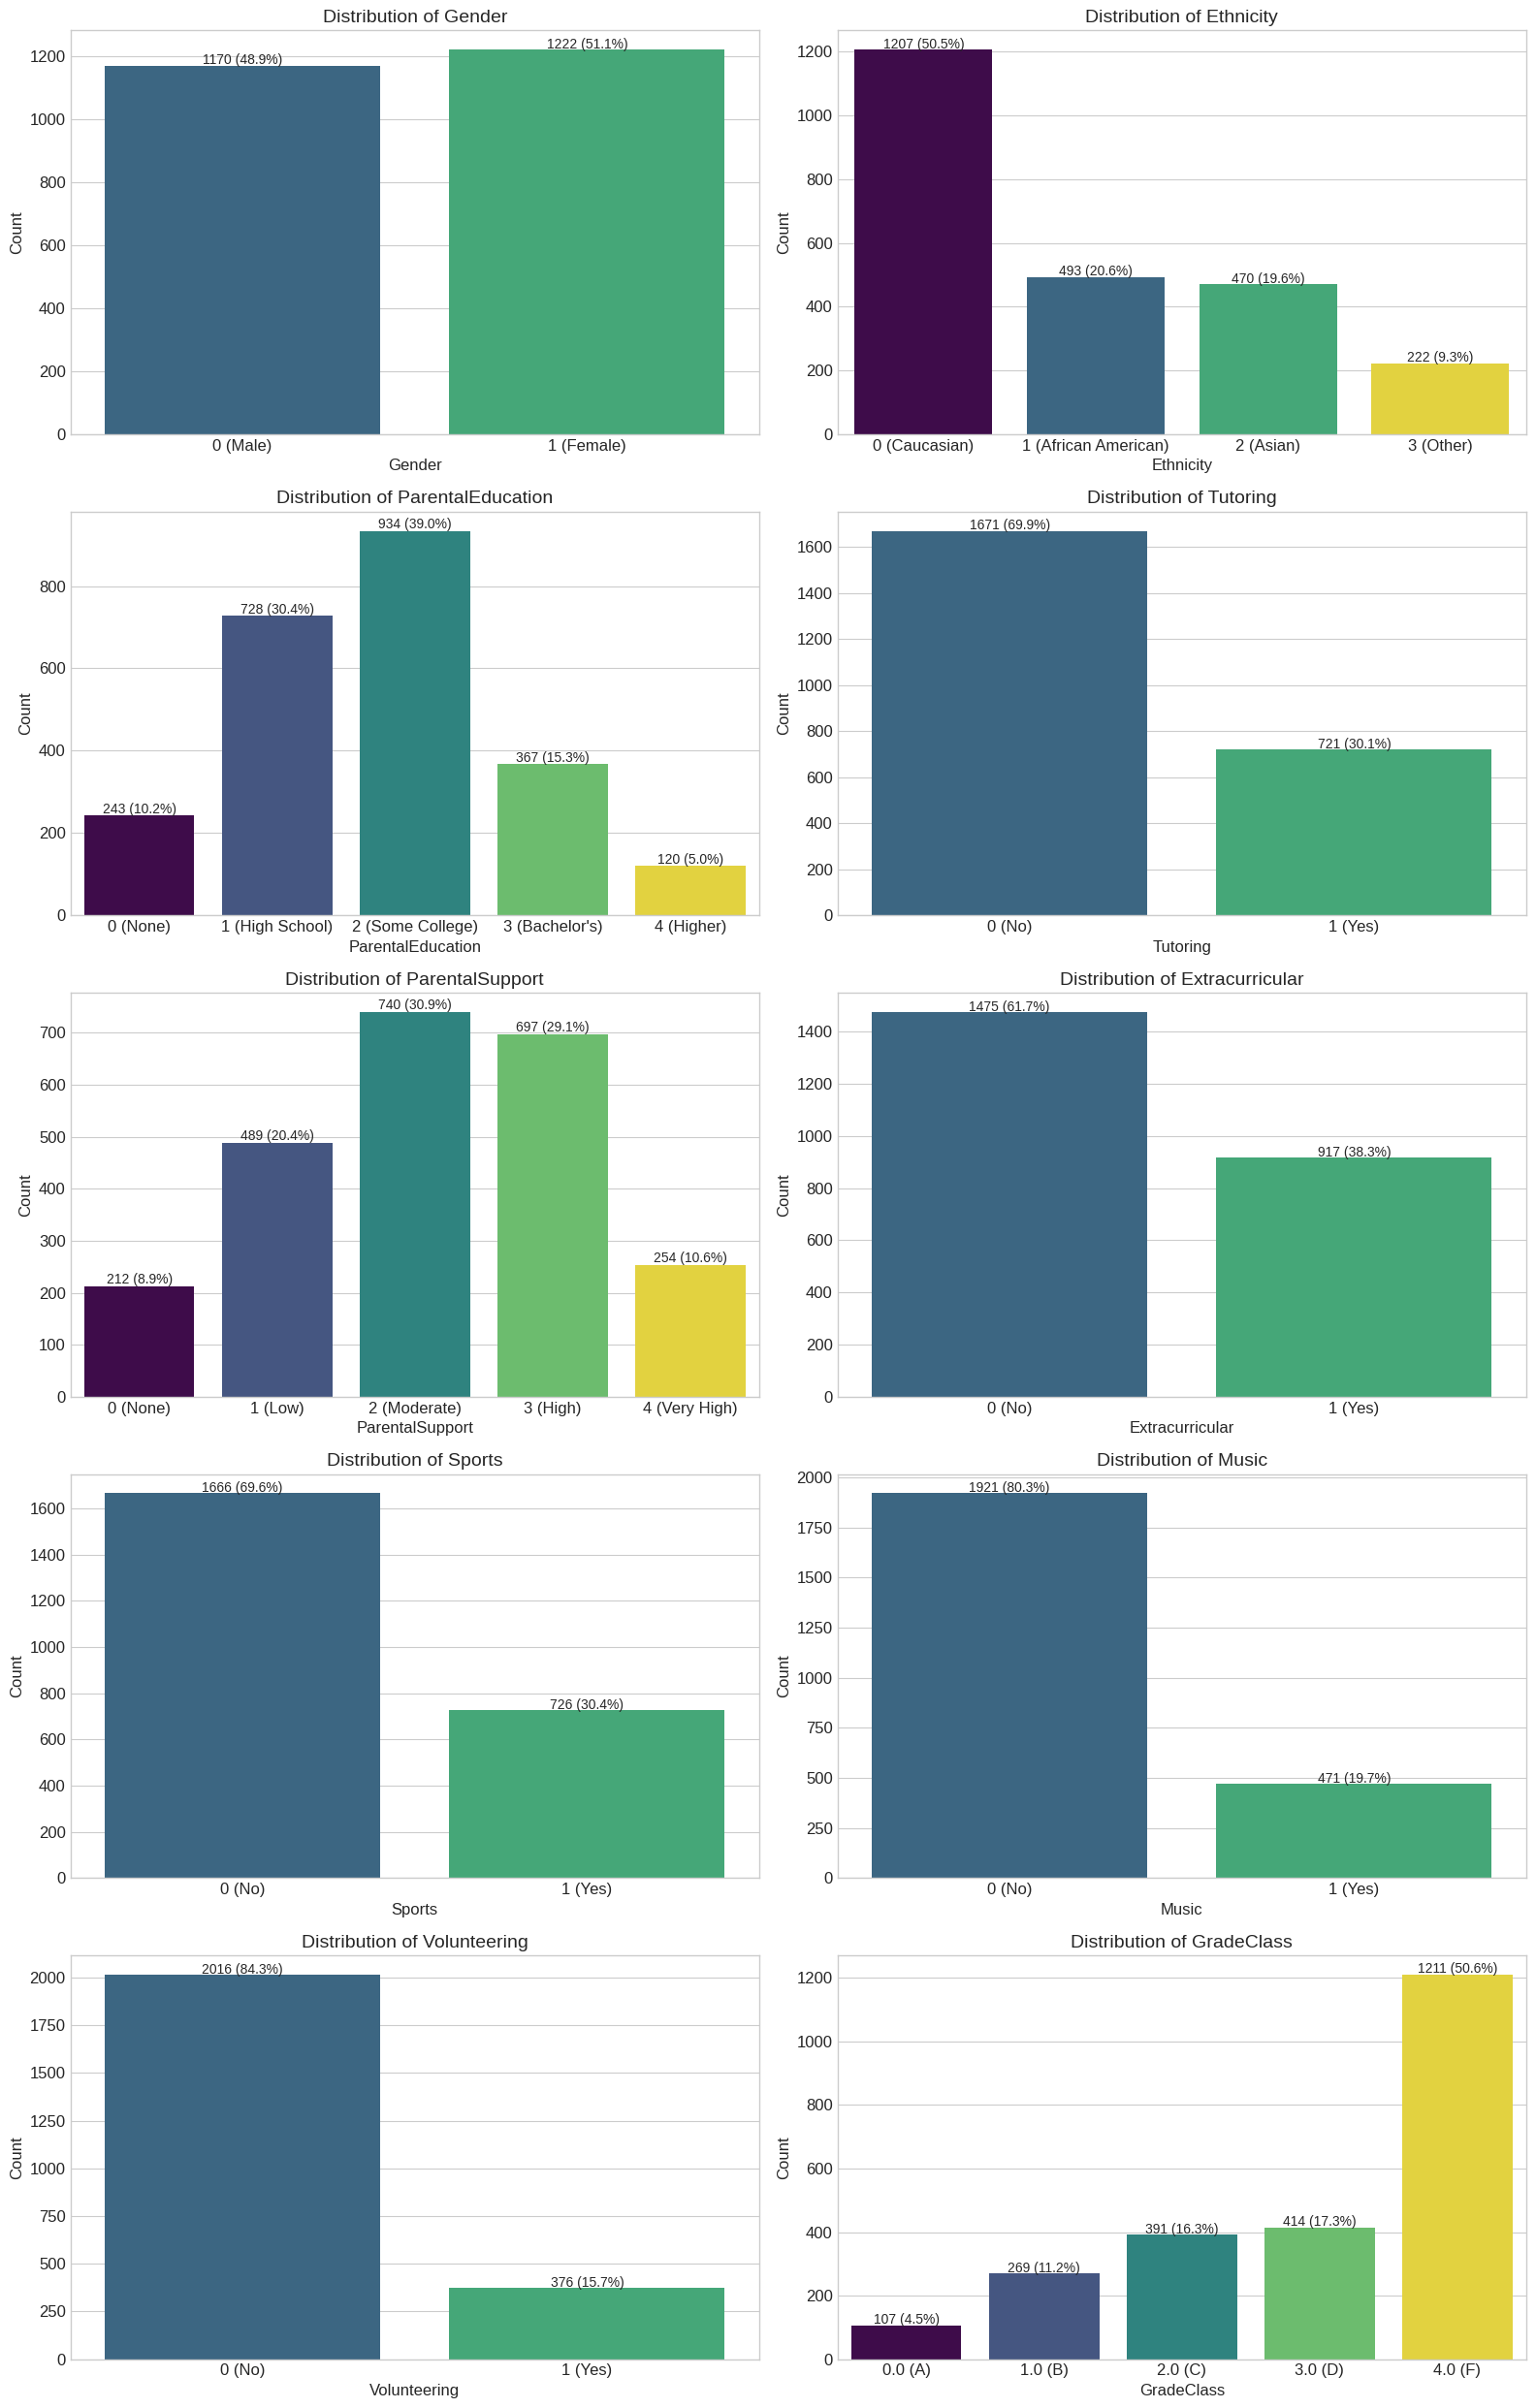

2025-05-01 20:01:46,497 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-01 20:01:46,504 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-01 20:01:46,558 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-01 20:01:46,565 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-01 20:01:46,653 - INFO - Using categorical units to plot a list of strings that are all parsable as 


🔍 RELATIONSHIPS BETWEEN CATEGORICAL VARIABLES AND ACADEMIC PERFORMANCE


2025-05-01 20:01:46,768 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-01 20:01:46,775 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-01 20:01:46,869 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-01 20:01:46,875 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-01 20:01:47,006 - INFO - Using categorical units to plot a list of strings that are all parsable as 

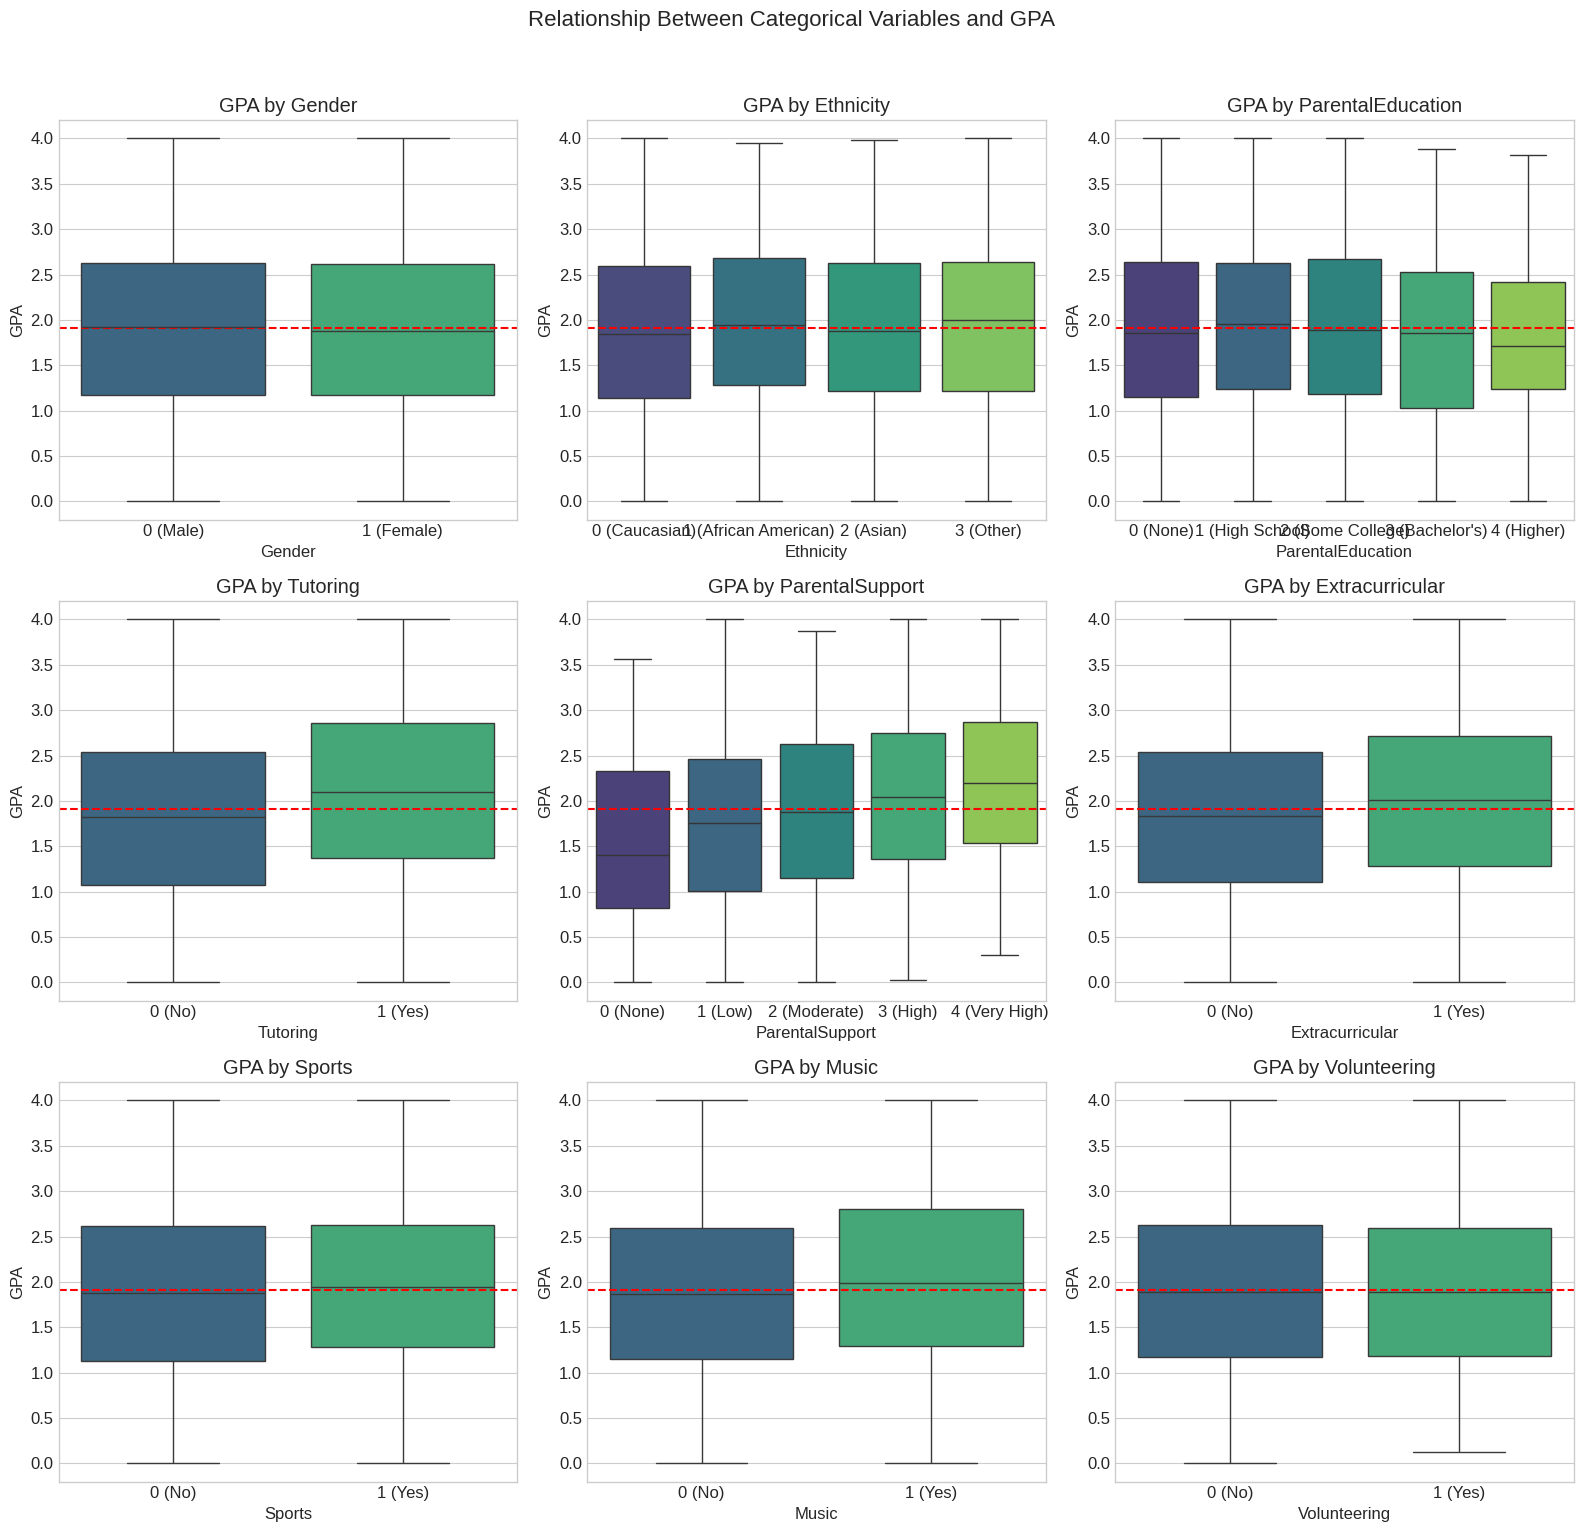

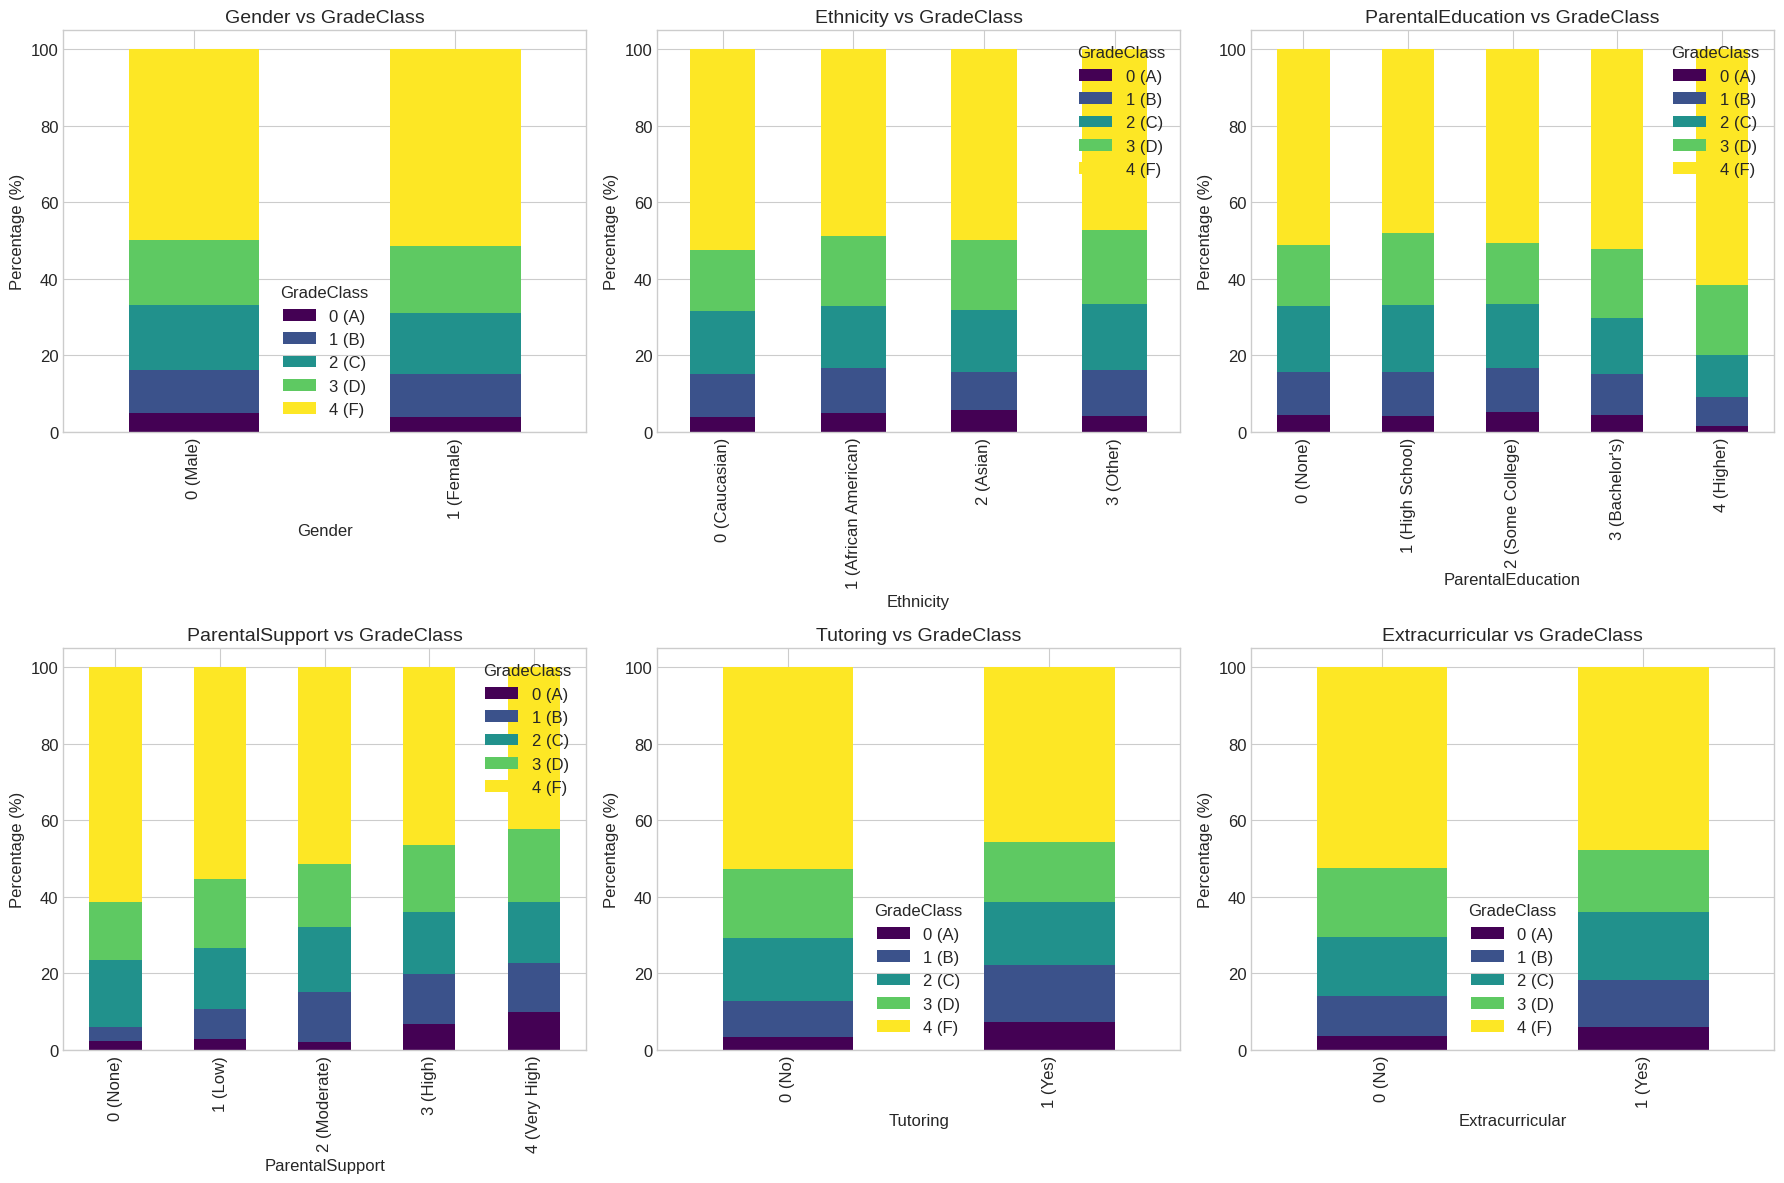

In [4]:
categorical_cols = ['Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring', 
                    'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 
                    'Volunteering', 'GradeClass']

# Display frequency distributions for categorical variables
print("📊 FREQUENCY DISTRIBUTION FOR CATEGORICAL VARIABLES")
print("="*80)

for col in categorical_cols:
    # Calculate value counts and percentages
    value_counts = df[col].value_counts(dropna=False).sort_index()
    percentages = df[col].value_counts(dropna=False, normalize=True).sort_index() * 100
    
    # Combine into a DataFrame for display
    freq_dist = pd.DataFrame({
        'Count': value_counts,
        'Percentage (%)': percentages.round(2)
    })
    
    # Add category labels based on data dictionary
    if col == 'Gender':
        freq_dist.index = [f"{i} ({label})" for i, label in zip(freq_dist.index, ['Male', 'Female'])]
    elif col == 'Ethnicity':
        freq_dist.index = [f"{i} ({label})" for i, label in zip(freq_dist.index, ['Caucasian', 'African American', 'Asian', 'Other'])]
    elif col == 'ParentalEducation':
        freq_dist.index = [f"{i} ({label})" for i, label in zip(freq_dist.index, ['None', 'High School', 'Some College', 'Bachelor\'s', 'Higher'])]
    elif col == 'ParentalSupport':
        freq_dist.index = [f"{i} ({label})" for i, label in zip(freq_dist.index, ['None', 'Low', 'Moderate', 'High', 'Very High'])]
    elif col in ['Tutoring', 'Extracurricular', 'Sports', 'Music', 'Volunteering']:
        freq_dist.index = [f"{i} ({label})" for i, label in zip(freq_dist.index, ['No', 'Yes'])]
    elif col == 'GradeClass':
        freq_dist.index = [f"{i} ({label})" for i, label in zip(freq_dist.index, ['A', 'B', 'C', 'D', 'F'])]
    
    print(f"\n{col} Distribution:")
    display(freq_dist)

# Create visualizations for categorical variables
print("\n📈 VISUALIZATION OF CATEGORICAL VARIABLES")
print("="*80)

# Calculate number of rows needed for subplot grid
n_rows = (len(categorical_cols) + 1) // 2  # Ceiling division

# Create subplots
fig, axes = plt.subplots(n_rows, 2, figsize=(16, 5*n_rows))
axes = axes.flatten()

# Dictionary to map numeric values to labels for each categorical variable
label_mappings = {
    'Gender': {0: 'Male', 1: 'Female'},
    'Ethnicity': {0: 'Caucasian', 1: 'African American', 2: 'Asian', 3: 'Other'},
    'ParentalEducation': {0: 'None', 1: 'High School', 2: 'Some College', 3: 'Bachelor\'s', 4: 'Higher'},
    'Tutoring': {0: 'No', 1: 'Yes'},
    'ParentalSupport': {0: 'None', 1: 'Low', 2: 'Moderate', 3: 'High', 4: 'Very High'},
    'Extracurricular': {0: 'No', 1: 'Yes'},
    'Sports': {0: 'No', 1: 'Yes'},
    'Music': {0: 'No', 1: 'Yes'},
    'Volunteering': {0: 'No', 1: 'Yes'},
    'GradeClass': {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'F'}
}

# Plot each categorical variable
for i, col in enumerate(categorical_cols):
    # Get value counts
    counts = df[col].value_counts().sort_index()
    
    # Create a DataFrame for the barplot to use proper seaborn syntax
    plot_df = pd.DataFrame({
        'Category': counts.index, 
        'Count': counts.values
    })
    
    # Create labels for categories
    category_labels = [f"{val} ({label_mappings[col][val]})" for val in counts.index]
    
    # Use the updated barplot syntax
    ax = axes[i]
    bars = sns.barplot(x='Category', y='Count', data=plot_df, ax=ax, hue='Category', 
                       palette='viridis', legend=False)
    
    # Add data labels on top of bars
    for j, p in enumerate(bars.patches):
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2.,
                height + 5,
                f'{int(height)} ({counts.values[j]/len(df)*100:.1f}%)',
                ha="center", fontsize=10)
    
    # Set custom x-tick labels correctly
    ax.set_xticks(range(len(category_labels)))
    ax.set_xticklabels(category_labels)
    
    # Set titles and labels
    ax.set_title(f'Distribution of {col}', fontsize=14)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

# Hide any unused subplots
for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Analyze relationships between categorical variables and GPA/GradeClass
print("\n🔍 RELATIONSHIPS BETWEEN CATEGORICAL VARIABLES AND ACADEMIC PERFORMANCE")
print("="*80)

# Set up figure for relationship with GPA
plt.figure(figsize=(16, 15))

# Plot GPA across different categorical variables (excluding GradeClass)
for i, col in enumerate([c for c in categorical_cols if c != 'GradeClass']):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=col, y='GPA', data=df, palette='viridis')
    
    # Add horizontal reference line for mean GPA
    plt.axhline(y=df['GPA'].mean(), color='red', linestyle='--', label=f'Mean GPA: {df["GPA"].mean():.2f}')
    
    # Set custom x-tick labels with category descriptions
    plt.xticks(range(len(label_mappings[col])), 
               [f"{i} ({label_mappings[col][i]})" for i in range(len(label_mappings[col]))])
    
    plt.title(f'GPA by {col}')
    plt.tight_layout()

plt.suptitle('Relationship Between Categorical Variables and GPA', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Stacked bar charts to show relationships between categorical variables
selected_categorical_pairs = [
    ('Gender', 'GradeClass'),
    ('Ethnicity', 'GradeClass'),
    ('ParentalEducation', 'GradeClass'),
    ('ParentalSupport', 'GradeClass'),
    ('Tutoring', 'GradeClass'),
    ('Extracurricular', 'GradeClass')
]

# Create subplots for stacked bar charts
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (cat1, cat2) in enumerate(selected_categorical_pairs):
    # Calculate the contingency table
    contingency = pd.crosstab(df[cat1], df[cat2], normalize='index') * 100
    
    # Create stacked bar chart
    contingency.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis')
    
    # Set custom x-tick labels with category descriptions
    current_labels = axes[i].get_xticklabels()
    new_x_labels = [f"{j} ({label_mappings[cat1][j]})" for j in range(len(current_labels))]
    axes[i].set_xticklabels(new_x_labels)
    
    # Fix the legend labels
    handles, labels = axes[i].get_legend_handles_labels()
    
    # Convert labels safely to match the GradeClass mapping
    new_labels = []
    for label in labels:
        # Handle various possible string formats by extracting just the number part
        try:
            # Try to extract just the first character which should be the number
            num = float(label.split('.')[0])
            int_num = int(num)
            new_labels.append(f"{int_num} ({label_mappings[cat2][int_num]})")
        except (ValueError, KeyError):
            # If conversion fails, just use the original label
            new_labels.append(label)
    
    axes[i].legend(handles, new_labels, title=cat2)
    
    axes[i].set_title(f'{cat1} vs {cat2}', fontsize=14)
    axes[i].set_xlabel(cat1)
    axes[i].set_ylabel('Percentage (%)')

plt.tight_layout()
plt.show()

#### 🎯 **Key Insights from Categorical Feature Analysis**

Analyzing the categorical features reveals several compelling patterns that can inform both exploratory analysis and model design:

- 🔄 **Gender is Balanced**: The gender distribution is nearly equal — 48.91% male and 51.09% female — providing a well-balanced foundation for unbiased gender-based analysis.

- 🌍 **Ethnically Diverse Sample**: Students come from varied ethnic backgrounds: 50.46% Caucasian, 20.61% African American, 19.85% Asian, and 9.28% Other. Interestingly, GPA and grade distributions remain relatively consistent across ethnicities, suggesting ethnicity may not play a dominant role in academic outcomes.

- 🎓 **Parental Education Makes a Difference**: A majority of parents have at least a high school diploma or some college education. While subtle, there's a clear trend — students with more highly educated parents (Bachelor’s or Higher) tend to have slightly higher GPAs, hinting at an intergenerational effect on academic performance.

- 📘 **Tutoring Helps, But Few Receive It**: Only 30.14% of students receive tutoring. However, those who do show a modest GPA boost (median ~2.0 vs. ~1.8), suggesting that increasing access to tutoring could yield academic gains.

- 👪 **Parental Support is a Game-Changer**: Strong parental support correlates with improved performance — students with “Very High” support have a noticeably higher chance of securing A grades. This underscores the value of emotional and academic reinforcement at home.

- 🏫 **Extracurricular Activities Offer an Edge**: 38.38% of students are involved in extracurriculars, and they generally perform slightly better (median GPA ~2.0). Engagement beyond the classroom seems to promote well-rounded academic development.

- ⚽ **Sports & 🎵 Music: Low Participation, Low Impact**: Sports (30.35%) and music (19.69%) participation is relatively low. While these activities offer personal and social benefits, they show minimal correlation with GPA or grade distribution in this dataset.

- 🤝 **Volunteering is Limited**: Just 15.72% of students participate in volunteering, and its impact on academic performance appears minimal — though it might contribute more to non-academic skills and character development.

- ⚠️ **Severe Class Imbalance in Performance**: More than half the students fall into GradeClass 4 (F). This imbalance persists across nearly all categorical groups, presenting a serious challenge for predictive modeling — especially for algorithms sensitive to class distribution.

These insights illuminate the subtle but significant ways categorical factors shape academic outcomes — and highlight which variables deserve closer attention during modeling.

---

# **🔍 Data Exploration and Preprocessing**

In this stage, we focus on preparing the dataset for modeling by performing the following key steps:

- **Handling Missing Values**: Identify and address any missing or null values in the dataset to ensure data integrity. This may involve removing rows, imputing with statistical measures (mean, median, or mode), or using domain-specific logic.

- **Data Normalization or Standardization**: If required, scale numerical features using techniques like Min-Max Normalization or Z-score Standardization to ensure that features with different units or ranges contribute equally to model training.

- **Correlation Analysis**: Examine the relationship between independent variables and the target variable using correlation coefficients and visualizations (e.g., heatmaps). This helps identify highly predictive features and detect multicollinearity, which may affect model performance.

These steps ensure the data is clean, consistent, and well-structured — forming a solid foundation for building accurate and reliable predictive models.

## 🧹 **Dropping Irrelevant Features**

To streamline our dataset and avoid redundancy, we’ll remove features that do not contribute meaningful information to the classification task:

- **`StudentID`**: This is simply a unique identifier for each student and carries no predictive value. Hence, it can be safely dropped.
- **`GPA`**: Although this numeric score reflects academic performance, it's directly correlated with the target variable `GradeClass` (as it's used to derive it). Keeping both could lead to data leakage, so we’ll remove `GPA` and retain `GradeClass` as our primary target.

This step helps reduce noise and ensures the model learns from relevant and non-redundant data.

In [5]:
df = df.drop(['StudentID','GPA'], axis = 1)
df.head()

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GradeClass
0,17,1,0,2,19.834,7,1,2,0,0,1,0,2.000
1,18,0,0,1,15.409,0,0,1,0,0,0,0,1.000
2,15,0,2,3,4.211,26,0,2,0,0,0,0,4.000
3,17,1,0,3,10.029,14,0,3,1,0,0,0,3.000
4,17,1,0,2,4.672,17,1,3,0,0,0,0,4.000


## 🧩 **Checking for Missing Values**

Before diving deeper into data modeling, it's essential to ensure that our dataset is complete and consistent.  

In [6]:
df.isnull().sum()

Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GradeClass           0
dtype: int64

There are no missing values in our data, good.

## **🔧 Feature Engineering**

To enhance the model's ability to capture deeper patterns in the data, we introduced several engineered features based on logical combinations and mathematical transformations of the original variables.

### **✨ Custom Features**
1. **ParentalEducation_StudyTime**:  
   This feature multiplies the parental education level with the student's weekly study time. It reflects the assumption that students with more educated parents may benefit more from each hour of study, as they might receive better guidance or support at home.

2. **StudyAbsenceRatio**:  
   This feature represents the efficiency of a student’s learning by comparing study time to the number of absences. A higher value suggests more focused academic behavior, while a lower value may indicate that time spent studying is being undercut by frequent absenteeism.

### **🔄 Polynomial Expansion**
We also applied a second-degree polynomial transformation to the main numerical features. This approach creates additional features representing all combinations and squared terms of the original variables. By doing so, the model is empowered to learn non-linear relationships and interactions that might be invisible in the raw data alone.

In [7]:
df['ParentalEducation_StudyTime'] = df['ParentalEducation'] * df['StudyTimeWeekly']
df['StudyAbsenceRatio'] = df['StudyTimeWeekly'] / (df['Absences'] + 1)

numerical_features = df[['Age', 'StudyTimeWeekly', 'Absences', 'ParentalEducation_StudyTime', 'StudyAbsenceRatio']]

poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
poly_features = poly.fit_transform(numerical_features)

poly_features_df = pd.DataFrame(poly_features, columns=poly.get_feature_names_out(numerical_features.columns))

df = pd.concat([df, poly_features_df], axis=1)

## **🧹 Removing Duplicate Columns**

To ensure the dataset is clean and efficient, the next step is to check and remove any **duplicate columns**. These can arise during the feature engineering process or data merging, and they can lead to unnecessary complexity, slow down model training, and potentially introduce multicollinearity.

By eliminating duplicates, we ensure that the model works with the most relevant and unique features, allowing for better performance and faster computation.

In [8]:
## Remove duplicate columns if any
df = df.loc[:, ~df.columns.duplicated()]

## **⛏ Data Splitting**

Before proceeding to the next steps, such as standardization or model training, it's essential to **split the dataset** into training and testing sets. This division ensures that we can evaluate the performance of our models on unseen data, helping to prevent overfitting and ensuring the generalizability of the model.

Typically, the data is split into:
- **Training Set**: Used to train the model and learn the relationships between features and the target variable.
- **Testing Set**: Used to evaluate the model's performance and assess its ability to generalize to new, unseen data.

This process forms the foundation of a robust machine learning pipeline, ensuring that the model performs well not just on the training data, but also in real-world applications.

In [9]:
X = df.drop('GradeClass', axis=1)
y = df['GradeClass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## ⚙️ Scaling

After splitting the data, the next crucial step is **scaling**. This step is especially important when working with machine learning models that are sensitive to the scale of the features, such as distance-based algorithms (e.g., K-Nearest Neighbors, SVM) or gradient-based optimization models (e.g., Logistic Regression, Neural Networks).

Scaling ensures that all features contribute equally to the model by transforming them into a similar range. This prevents features with larger ranges from dominating the model's behavior.

There are two common methods:
- **Standardization** (Z-score normalization): This transforms the features so that they have a mean of 0 and a standard deviation of 1.
- **Normalization** (Min-Max scaling): This rescales the features to a fixed range, usually between 0 and 1.

For this particular case, we gonna use **StandardScaler**

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---

# **Modelling 🚀**

In this stage, we dive deep into applying machine learning models to predict outcomes and uncover insights from our dataset. Here's how we’ll roll:

1. **Model Selection 🔍**: We’ll evaluate a variety of classification models like Logistic Regression, K-Nearest Neighbors (KNN), Naive Bayes, and Decision Trees, each bringing its own strengths to the table. It's like choosing the right tool for the job!

2. **Hyperparameter Tuning ⚙️**: Next, we’ll fine-tune each model by using **grid search** to find the optimal combination of hyperparameters. Think of it as tweaking the gears to get the best performance!

3. **Model Evaluation 📊**: Time to assess how well our models are performing. We’ll use metrics like **accuracy**, **precision**, **recall**, **F1 score**, the **confusion matrix**, and **ROC curves** to get a comprehensive view of how each model is performing.

4. **Feature Importance Analysis 📈**: Let’s uncover which features are the most influential! We'll use **Logistic Regression** and **Decision Tree** models to pinpoint the key predictors that have the greatest impact on predictions. This will help us understand what really drives the results!

## **🪛 Setup and Class Weighting**

Before evaluating our models, we set up a few important components:

1. **Evaluation Metrics 📊**: We define a function to assess model performance, calculate key metrics (accuracy, precision, recall, F1 score), and visualize results using classification reports, confusion matrices, and ROC curves.

2. **Class Weighting ⚖️**: To address class imbalance, we compute class weights to ensure the model doesn't favor the majority class.

3. **Cross-Validation 🔄**: We use **Stratified K-Fold** cross-validation to maintain consistent class distribution across folds, ensuring reliable evaluations.

In [11]:
# Create a dictionary to store evaluation metrics for all models
all_metrics = []

# Function to evaluate and visualize model performance
def evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test, model_name):
    """
    Evaluates model performance and creates visualizations.
    
    Args:
        model: Trained classifier model
        X_train_scaled: Scaled training features
        X_test_scaled: Scaled testing features
        y_train: Training target variable
        y_test: Testing target variable
        model_name: Name of the model for display purposes
        
    Returns:
        metrics_dict: Dictionary containing evaluation metrics
    """
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = None
    
    # Check if the model supports probability predictions
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test_scaled)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average='macro')
    recall_macro = recall_score(y_test, y_pred, average='macro')
    f1_macro = f1_score(y_test, y_pred, average='macro')
    
    # Store metrics in dictionary
    metrics_dict = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision (macro)': precision_macro,
        'Recall (macro)': recall_macro,
        'F1 Score (macro)': f1_macro
    }
    
    # Print metrics
    print(f"\n{'-'*20} {model_name} Evaluation {'-'*20}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (macro): {precision_macro:.4f}")
    print(f"Recall (macro): {recall_macro:.4f}")
    print(f"F1 Score (macro): {f1_macro:.4f}")
    
    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=[f'Grade {i}' for i in range(len(np.unique(y_test)))]))
    
    # Create confusion matrix
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'Grade {i}' for i in range(len(np.unique(y_test)))],
                yticklabels=[f'Grade {i}' for i in range(len(np.unique(y_test)))])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.show()
    
    # If model supports probabilities, plot ROC curves
    if y_pred_proba is not None:
        # For multiclass, use one-vs-rest approach
        n_classes = len(np.unique(y_test))
        
        if n_classes > 2:
            # Binarize the output for multi-class ROC
            y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
            
            # Plot ROC curves
            plt.figure(figsize=(12, 8))
            
            for i in range(n_classes):
                fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
                roc_auc = auc(fpr, tpr)
                plt.plot(fpr, tpr, lw=2, 
                        label=f'ROC curve for Grade {i} (AUC = {roc_auc:.2f})')
            
            plt.plot([0, 1], [0, 1], 'k--', lw=2)
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'ROC Curves - {model_name}')
            plt.legend(loc="lower right")
            plt.show()
        
        else:  # Binary classification
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
            roc_auc = auc(fpr, tpr)
            
            plt.figure(figsize=(10, 8))
            plt.plot(fpr, tpr, color='darkorange', lw=2, 
                    label=f'ROC curve (AUC = {roc_auc:.2f})')
            plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'ROC Curve - {model_name}')
            plt.legend(loc="lower right")
            plt.show()
    
    return metrics_dict

# Computing class weights for handling imbalanced data
print("Computing class weights to handle class imbalance...")
class_counts = np.bincount(y_train.astype(int))
total_samples = len(y_train)

# Calculate class frequencies
class_frequencies = class_counts / total_samples
print(f"Class distribution: {class_frequencies}")

# Apply class weights (assuming imbalance exists)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to dictionary
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}
print(f"Class weights: {class_weights_dict}")

# Create cross-validation strategy (to be used for all models)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Computing class weights to handle class imbalance...
Class distribution: [0.04443283 0.11500261 0.15995818 0.17145844 0.50914794]
Class weights: {0: 4.501176470588235, 1: 1.739090909090909, 2: 1.250326797385621, 3: 1.1664634146341464, 4: 0.39281314168377823}


## **📈 Logistic Regression with Hyperparameter Tuning**

We now define and optimize our **Logistic Regression** model.

Using **GridSearchCV**, we explore various combinations of regularization strength (`C`), penalty types (`l1`, `l2`), and class weighting strategies to handle imbalance.  

The best model is selected based on **macro F1-score**, and then evaluated on the test set. ✅


📊 LOGISTIC REGRESSION
Performing hyperparameter tuning for Logistic Regression...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


Best parameters: {'C': 1, 'class_weight': {0: 4.501176470588235, 1: 1.739090909090909, 2: 1.250326797385621, 3: 1.1664634146341464, 4: 0.39281314168377823}, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation score: 0.5428

-------------------- Logistic Regression Evaluation --------------------
Accuracy: 0.6785
Precision (macro): 0.5035
Recall (macro): 0.4954
F1 Score (macro): 0.4988

Classification Report:
              precision    recall  f1-score   support

     Grade 0       0.16      0.14      0.15        22
     Grade 1       0.47      0.41      0.43        49
     Grade 2       0.53      0.52      0.52        85
     Grade 3       0.48      0.51      0.50        86
     Grade 4       0.88      0.90      0.89       237

    accuracy                           0.68       479
   macro avg       0.50      0.50      0.50       479
weighted avg       0.67      0.68      0.67       479



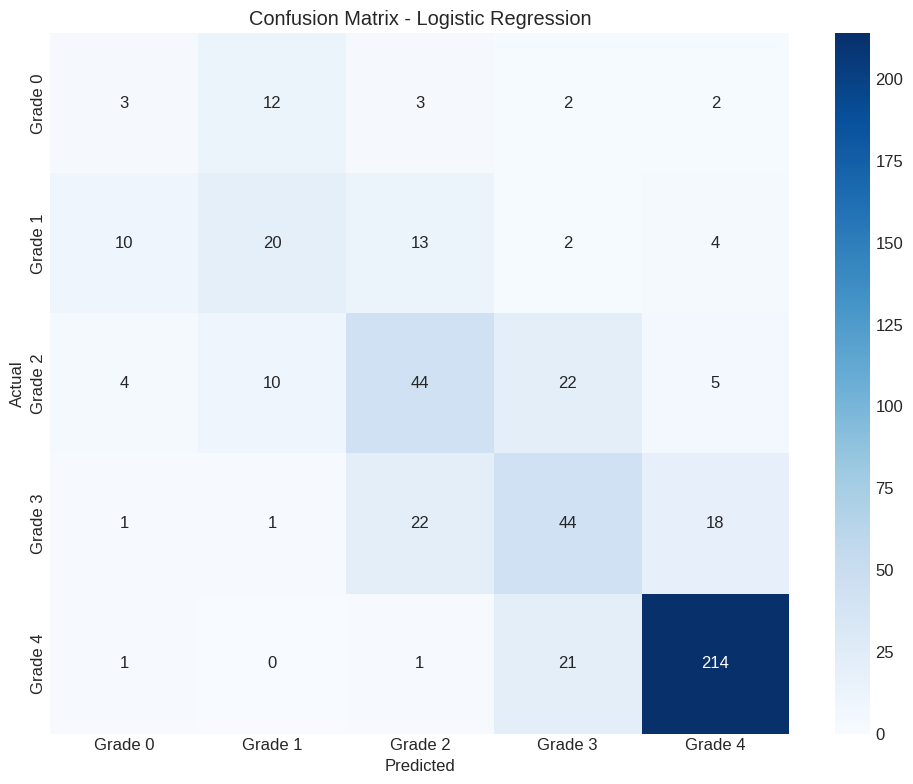

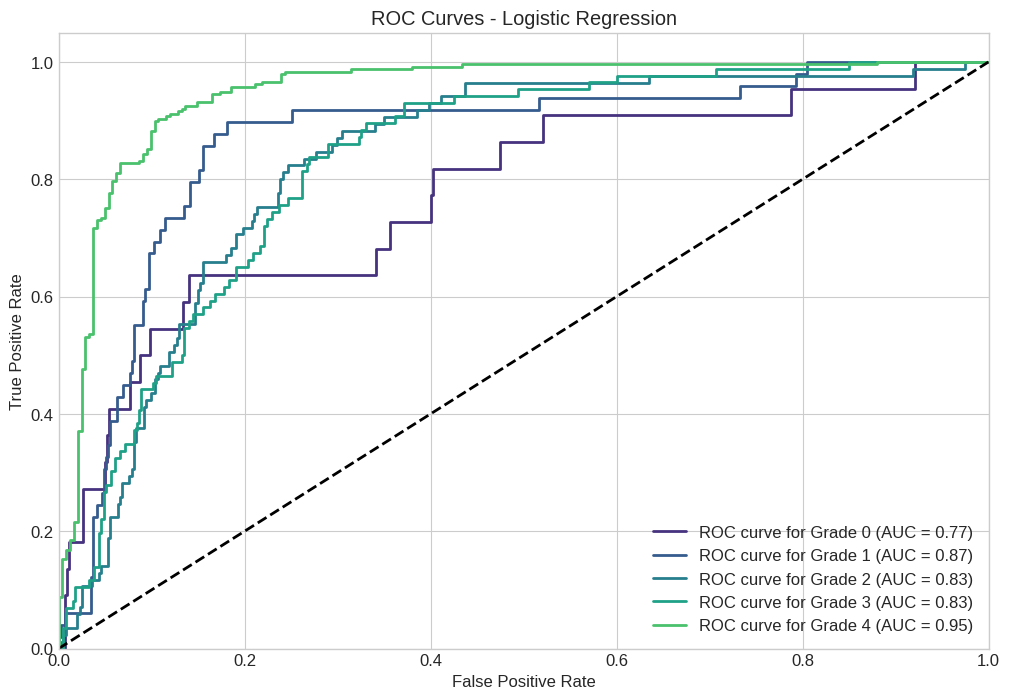

In [12]:
# Logistic Regression with hyperparameter tuning
print("\n📊 LOGISTIC REGRESSION")
print("="*80)
print("Performing hyperparameter tuning for Logistic Regression...")

# Define parameter grid
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [class_weights_dict, None]
}

# Create and train GridSearchCV
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=lr_param_grid,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_scaled, y_train)

# Get best model
lr_best = lr_grid.best_estimator_
print(f"Best parameters: {lr_grid.best_params_}")
print(f"Best cross-validation score: {lr_grid.best_score_:.4f}")

# Evaluate the model
lr_metrics = evaluate_model(lr_best, X_train_scaled, X_test_scaled, y_train, y_test, "Logistic Regression")
all_metrics.append(lr_metrics)

## **🔍K-Nearest Neighbors with Hyperparameter Tuning**

Next, we move on to **K-Nearest Neighbors (KNN)**.  

We tune key parameters like the number of neighbors (`n_neighbors`), distance metric (`p`), and weighting scheme (`weights`) using **GridSearchCV**. 

The optimal configuration is chosen based on the **macro F1-score**, and the final model is evaluated accordingly. 👣


🔍 K-NEAREST NEIGHBORS
Performing hyperparameter tuning for K-NN...
Fitting 5 folds for each of 28 candidates, totalling 140 fits
Best parameters: {'n_neighbors': 15, 'p': 1, 'weights': 'uniform'}
Best cross-validation score: 0.4901

-------------------- K-Nearest Neighbors Evaluation --------------------
Accuracy: 0.6263
Precision (macro): 0.4981
Recall (macro): 0.4192
F1 Score (macro): 0.4348

Classification Report:
              precision    recall  f1-score   support

     Grade 0       0.50      0.14      0.21        22
     Grade 1       0.42      0.31      0.35        49
     Grade 2       0.41      0.36      0.39        85
     Grade 3       0.37      0.36      0.36        86
     Grade 4       0.79      0.93      0.85       237

    accuracy                           0.63       479
   macro avg       0.50      0.42      0.43       479
weighted avg       0.60      0.63      0.60       479



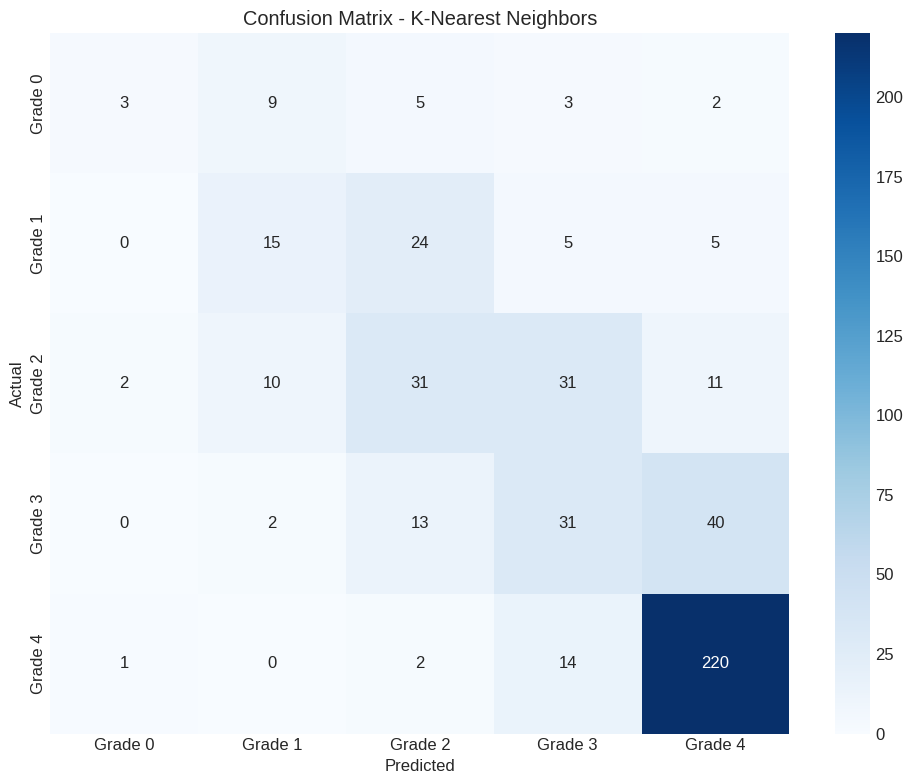

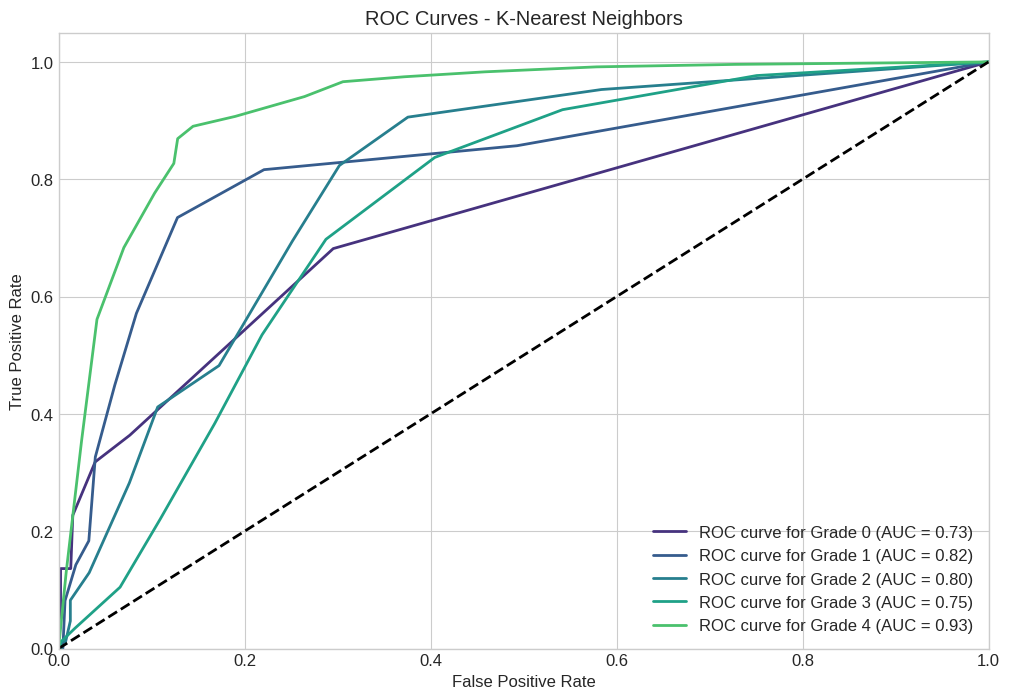

In [13]:
# K-Nearest Neighbors with hyperparameter tuning
print("\n🔍 K-NEAREST NEIGHBORS")
print("="*80)
print("Performing hyperparameter tuning for K-NN...")

# Define parameter grid
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # 1 for Manhattan, 2 for Euclidean
}

# Create and train GridSearchCV
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

knn_grid.fit(X_train_scaled, y_train)

# Get best model
knn_best = knn_grid.best_estimator_
print(f"Best parameters: {knn_grid.best_params_}")
print(f"Best cross-validation score: {knn_grid.best_score_:.4f}")

# Evaluate the model
knn_metrics = evaluate_model(knn_best, X_train_scaled, X_test_scaled, y_train, y_test, "K-Nearest Neighbors")
all_metrics.append(knn_metrics)

## **🧠Naive Bayes**

Now we train a **Gaussian Naive Bayes** model.  
Since it has no hyperparameters to tune, we assess its performance using **cross-validation** based on the **macro F1-score**.  
After that, we fit the model to the full training set and evaluate it on the test data. ⚙️📊



🧠 NAIVE BAYES
Training Gaussian Naive Bayes model...
Cross-validation scores: [0.46062867 0.41627193 0.53469367 0.42131102 0.43234535]
Mean CV score: 0.4531
Standard deviation: 0.0436

-------------------- Naive Bayes Evaluation --------------------
Accuracy: 0.6326
Precision (macro): 0.5280
Recall (macro): 0.4588
F1 Score (macro): 0.4518

Classification Report:
              precision    recall  f1-score   support

     Grade 0       0.38      0.14      0.20        22
     Grade 1       0.53      0.20      0.29        49
     Grade 2       0.43      0.33      0.37        85
     Grade 3       0.40      0.81      0.53        86
     Grade 4       0.91      0.81      0.86       237

    accuracy                           0.63       479
   macro avg       0.53      0.46      0.45       479
weighted avg       0.67      0.63      0.63       479



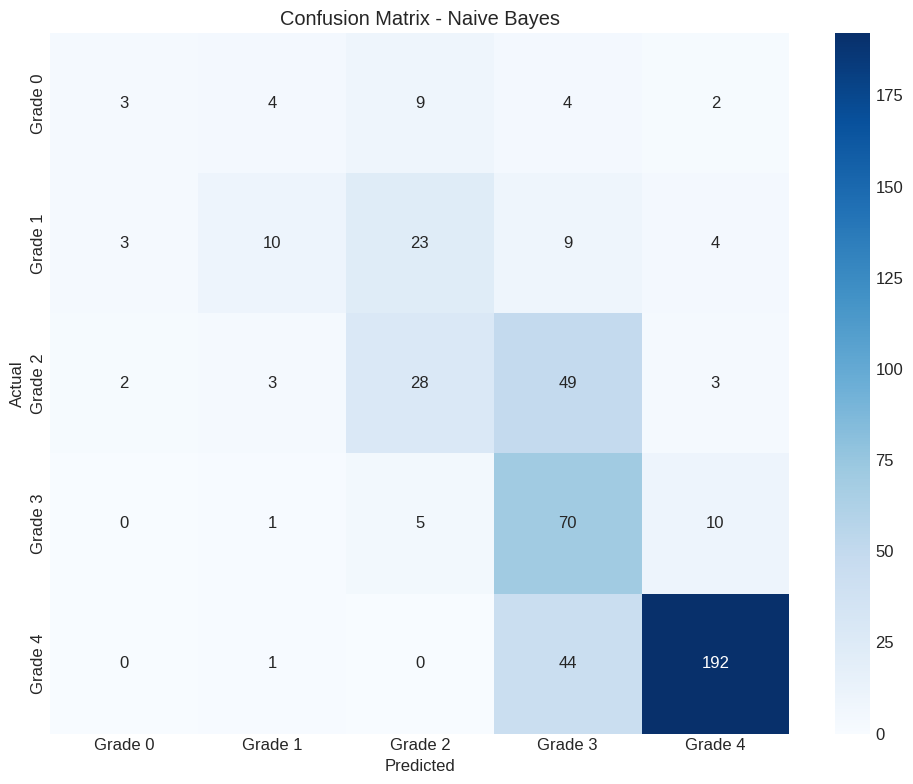

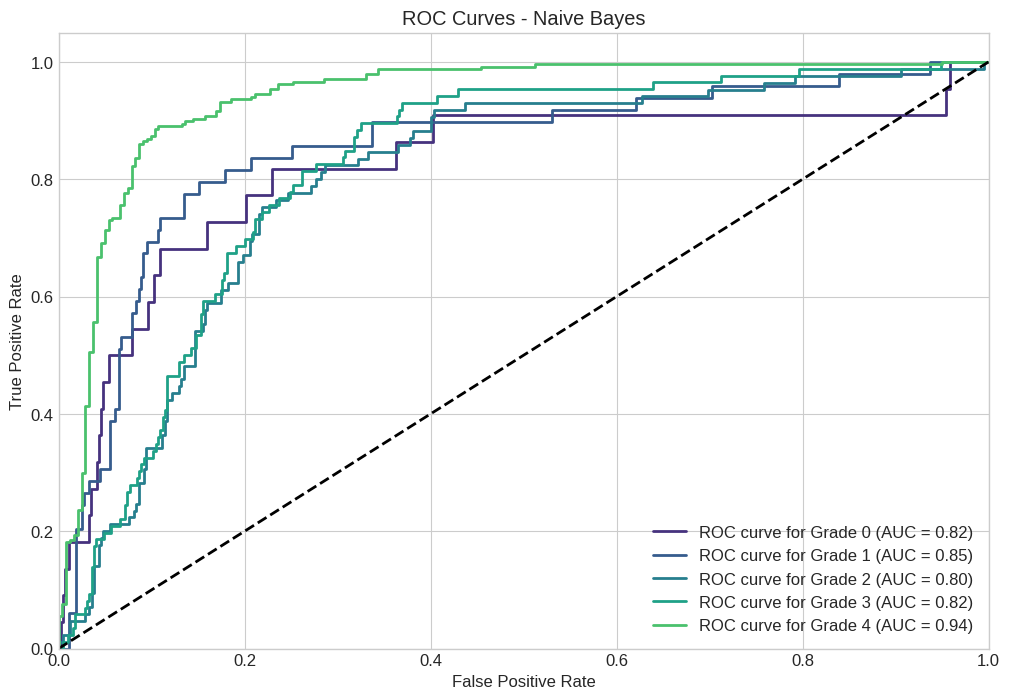

In [14]:
# Naive Bayes
print("\n🧠 NAIVE BAYES")
print("="*80)
print("Training Gaussian Naive Bayes model...")

# For Naive Bayes, we'll use cross-validation to assess performance
nb = GaussianNB()

# Perform cross-validation
cv_scores = cross_val_score(nb, X_train_scaled, y_train, cv=cv_strategy, scoring='f1_macro')
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV score: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")

# Train the model on the full training set
nb.fit(X_train_scaled, y_train)

# Evaluate the model
nb_metrics = evaluate_model(nb, X_train_scaled, X_test_scaled, y_train, y_test, "Naive Bayes")
all_metrics.append(nb_metrics)

## **🌳 Decision Tree With Hyperparameter Tuning**

Lastly, we tune and train a **Decision Tree classifier** using a grid search over key hyperparameters such as `max_depth`, `criterion`, and `min_samples_split`.  

Class weights are also considered to handle potential imbalance.  

After selecting the best model via **cross-validation**, we evaluate its performance and visualize the top layers of the tree for interpretability. 🧩📈



🌳 DECISION TREE
Performing hyperparameter tuning for Decision Tree...
Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best cross-validation score: 0.5210

-------------------- Decision Tree Evaluation --------------------
Accuracy: 0.6493
Precision (macro): 0.5306
Recall (macro): 0.4745
F1 Score (macro): 0.4812

Classification Report:
              precision    recall  f1-score   support

     Grade 0       0.50      0.14      0.21        22
     Grade 1       0.48      0.51      0.50        49
     Grade 2       0.44      0.48      0.46        85
     Grade 3       0.38      0.35      0.36        86
     Grade 4       0.85      0.89      0.87       237

    accuracy                           0.65       479
   macro avg       0.53      0.47      0.48       479
weighted avg       0.64      0.65      0.64       479



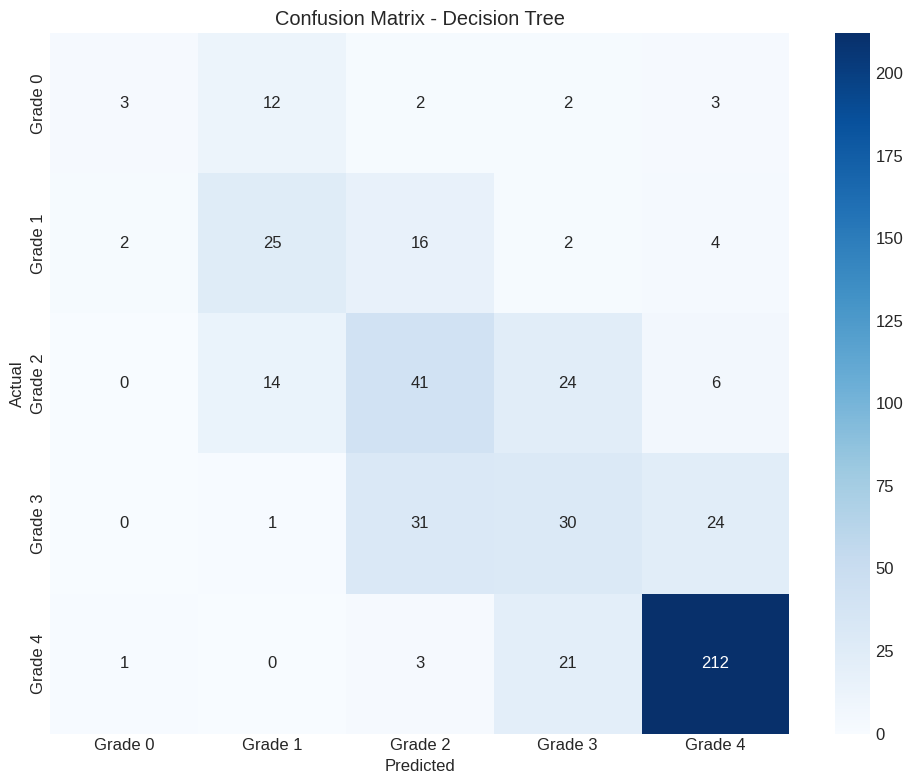

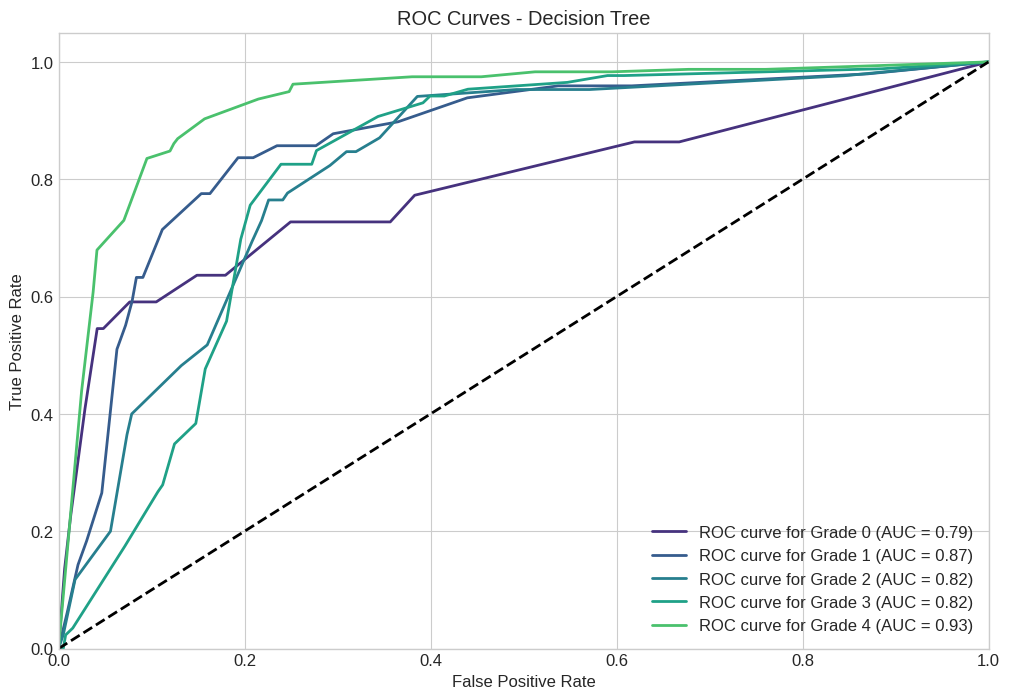

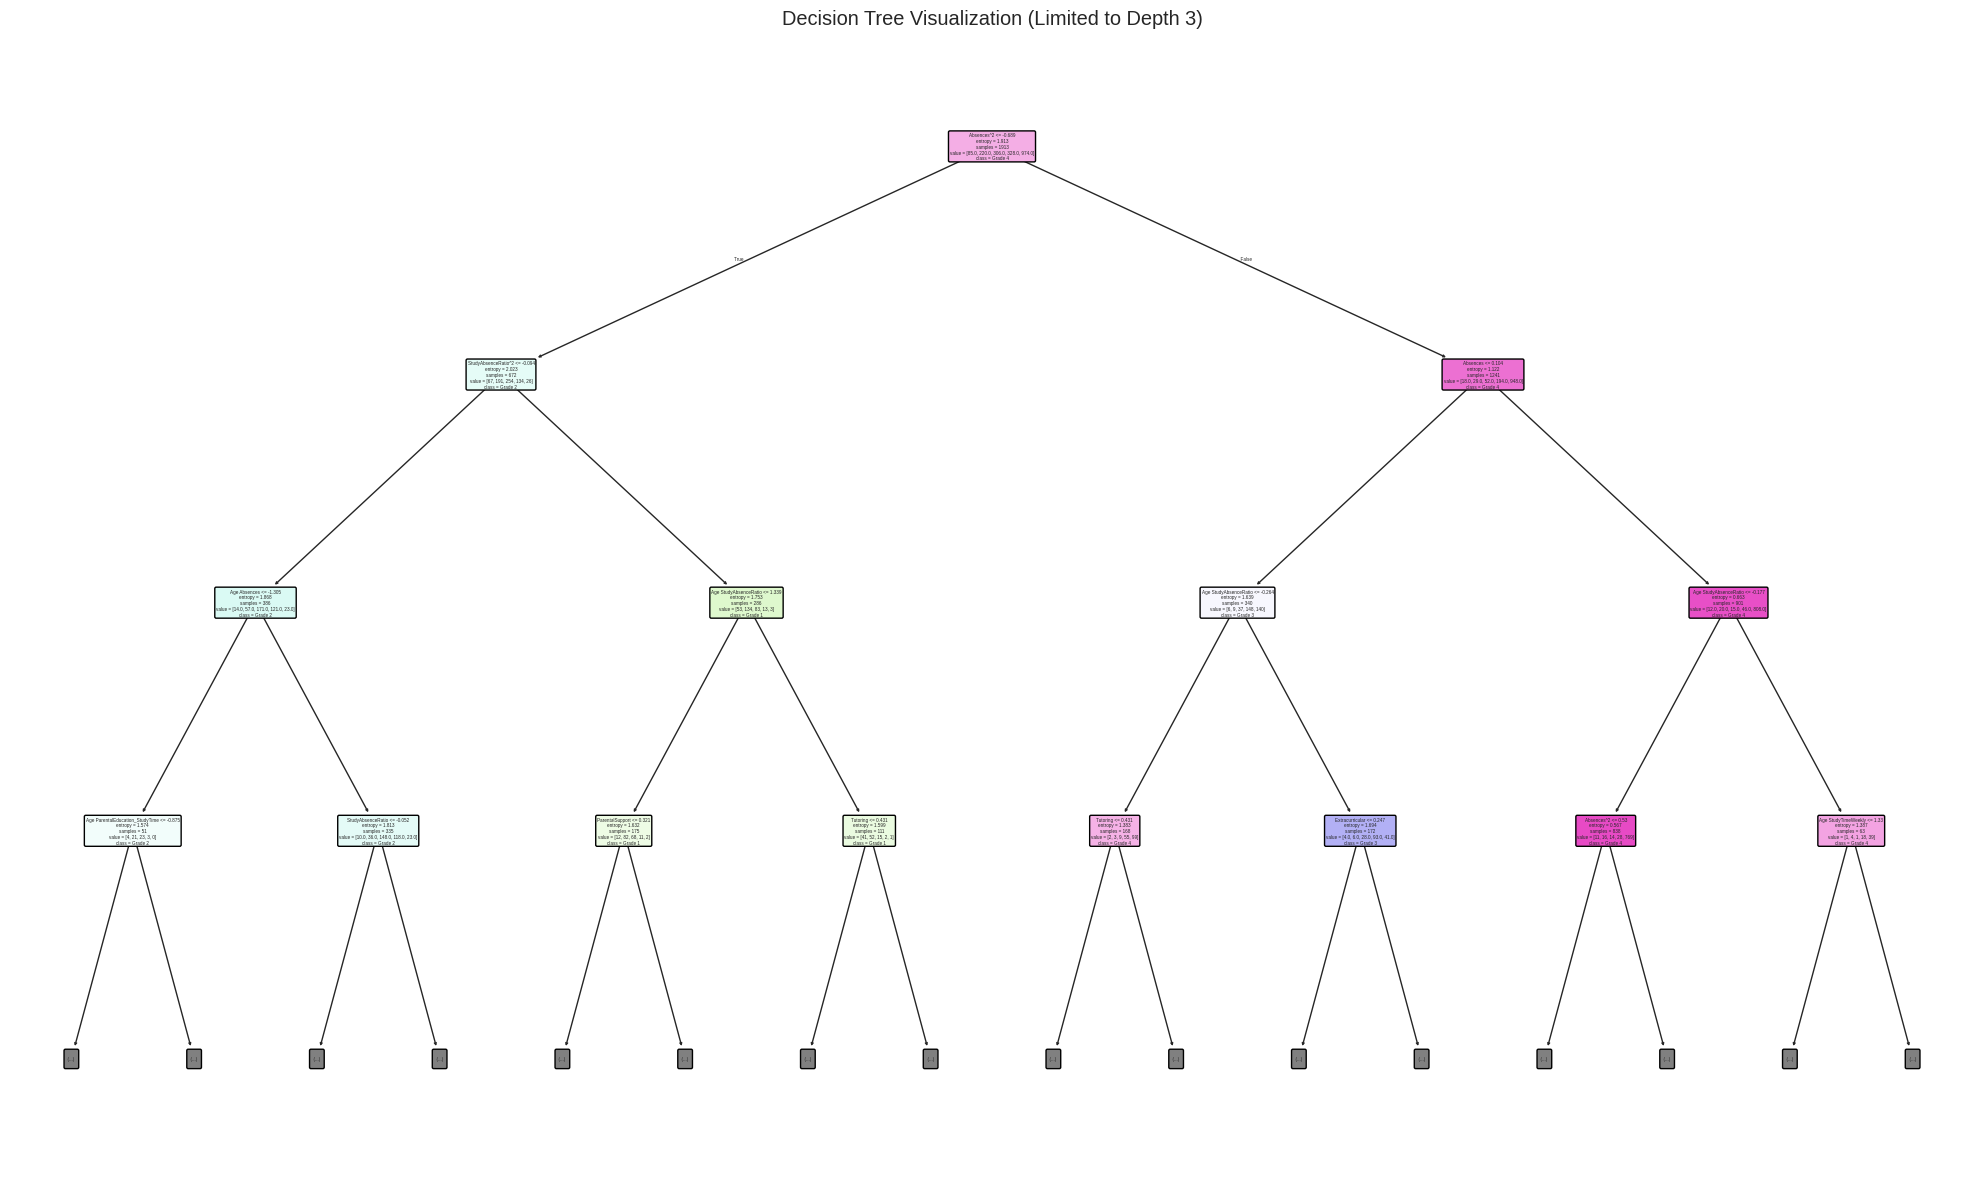

In [15]:
# Decision Tree with hyperparameter tuning
print("\n🌳 DECISION TREE")
print("="*80)
print("Performing hyperparameter tuning for Decision Tree...")

# Define parameter grid
dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [class_weights_dict, None]
}

# Create and train GridSearchCV
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train_scaled, y_train)

# Get best model
dt_best = dt_grid.best_estimator_
print(f"Best parameters: {dt_grid.best_params_}")
print(f"Best cross-validation score: {dt_grid.best_score_:.4f}")

# Evaluate the model
dt_metrics = evaluate_model(dt_best, X_train_scaled, X_test_scaled, y_train, y_test, "Decision Tree")
all_metrics.append(dt_metrics)

# Visualize the Decision Tree (limiting depth for readability)
plt.figure(figsize=(20, 12))
plot_tree(dt_best, 
          max_depth=3, 
          filled=True, 
          feature_names=X_train.columns, 
          class_names=[f'Grade {i}' for i in range(len(np.unique(y_test)))],
          rounded=True)
plt.title("Decision Tree Visualization (Limited to Depth 3)")
plt.tight_layout()
plt.show()

## **📊Model Evaluation and Visualization**

In this final step, we bring all models together for a comparative analysis:

- 📋 **Comparison Table & Bar Chart**: Summarize performance metrics across models to identify the top performers.
- 🔍 **Feature Importance**: Visualize the most influential features in **Logistic Regression** and **Decision Tree**.
- 🏆 **Final Recommendation**: Suggest the best model based on various evaluation priorities like F1 Score, Accuracy, and Recall.


📊 MODEL COMPARISON
Model Performance Comparison:


,Accuracy,Precision (macro),Recall (macro),F1 Score (macro)
Model,,,,
Logistic Regression,0.678,0.503,0.495,0.499
K-Nearest Neighbors,0.626,0.498,0.419,0.435
Naive Bayes,0.633,0.528,0.459,0.452
Decision Tree,0.649,0.531,0.474,0.481


<Figure size 1200x800 with 0 Axes>

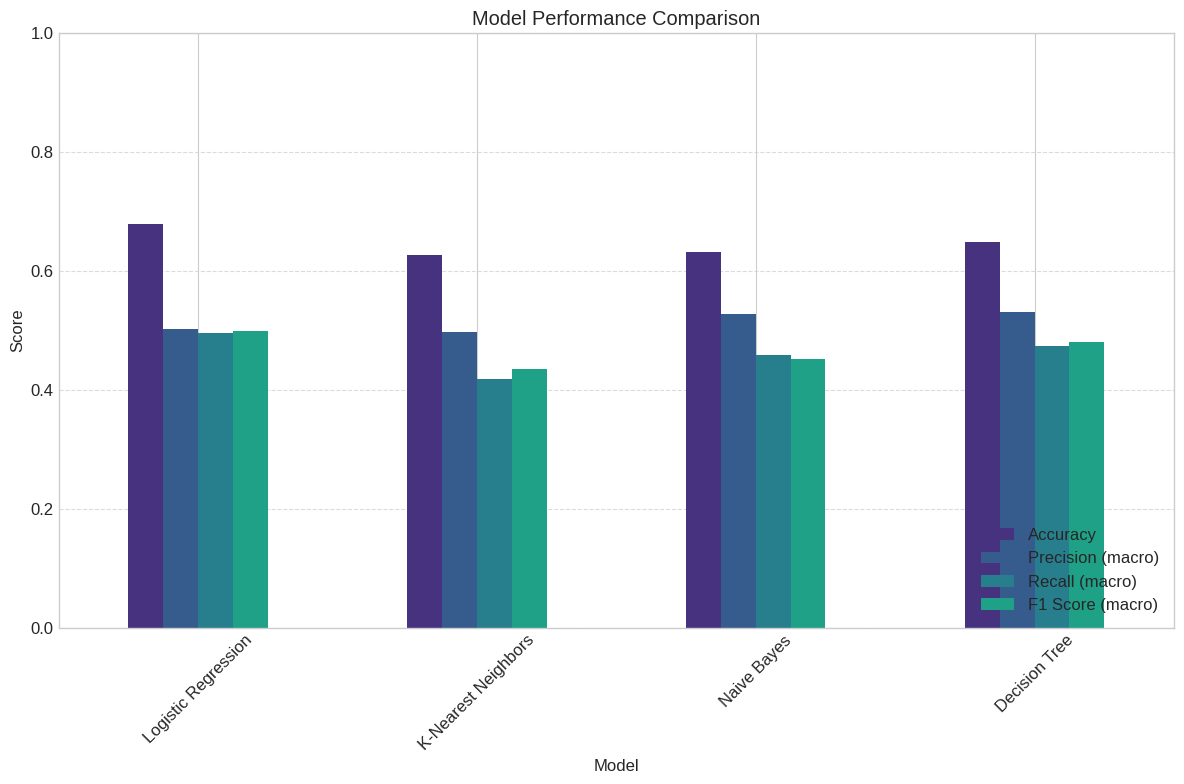


🏆 RECOMMENDATION: Based on F1 Score (macro), the best performing model is Logistic Regression

🔍 KEY INSIGHTS:
1. The models achieved the following accuracy scores:
   - Logistic Regression: 0.6785
   - K-Nearest Neighbors: 0.6263
   - Naive Bayes: 0.6326
   - Decision Tree: 0.6493

2. Performance considerations:
   - If balanced performance across all classes is important, consider using Logistic Regression (highest F1 macro score).
   - If overall accuracy is the priority, consider using Logistic Regression (highest accuracy).
   - If identifying positive cases correctly is crucial, consider using Logistic Regression (highest recall).


In [16]:
# Compare all models
print("\n📊 MODEL COMPARISON")
print("="*80)

# Create comparison dataframe
comparison_df = pd.DataFrame(all_metrics)
comparison_df = comparison_df.set_index('Model')

# Display comparison table
print("Model Performance Comparison:")
display(comparison_df)

# Plot comparison
plt.figure(figsize=(12, 8))
comparison_df.plot(kind='bar', figsize=(12, 8))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Final recommendation based on performance metrics
best_model = comparison_df['F1 Score (macro)'].idxmax()
print(f"\n🏆 RECOMMENDATION: Based on F1 Score (macro), the best performing model is {best_model}")

# insights
print("\n🔍 KEY INSIGHTS:")
print("1. The models achieved the following accuracy scores:")
for model in comparison_df.index:
    print(f"   - {model}: {comparison_df.loc[model, 'Accuracy']:.4f}")

print("\n2. Performance considerations:")
print(f"   - If balanced performance across all classes is important, consider using {comparison_df['F1 Score (macro)'].idxmax()} (highest F1 macro score).")
print(f"   - If overall accuracy is the priority, consider using {comparison_df['Accuracy'].idxmax()} (highest accuracy).")
print(f"   - If identifying positive cases correctly is crucial, consider using {comparison_df['Recall (macro)'].idxmax()} (highest recall).")